In [1]:
import kagglehub

# Descarga de dataset
path = kagglehub.dataset_download("neelagiriaditya/ufc-datasets-1994-2025")

print("Ruta de los ficheros:", path)

100%|██████████| 3.36M/3.36M [00:00<00:00, 30.3MB/s]

Extracting files...


Ruta de los ficheros: /root/.cache/kagglehub/datasets/neelagiriaditya/ufc-datasets-1994-2025/versions/3


#Dataset

##Composición del dataset

Este dataset se compone de 4 archivos.

**figther_details.csv** es donde tenemos guardados los datos de cada peleador que han pasado por la ufc tanto datos biometricos cómo datos en el combate.

**events_details.csv** aquí es donde los datos se ordenan por eventos, tenemos datos como cuando y donde se han realizado los eventos, las peleas que se han realizado en el mismo y el ganador de la pelea.

**fight_details.csv** en este archivo es donde se guardan los datos de cada pelea. Golpes a la cabeza lanzados, intentos derribo, round en el que se acabo la pelea etc..

**UFC.csv**: que es dataset principal que es donde está el conjunto de datos de los otros archivos anteriormente mencionados.

In [2]:
#Importamos las librerías
import pandas as pd
import re
import time
from sklearn.model_selection import GridSearchCV
import os
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import silhouette_score

#Cogemos los datasets con pandas
dataset_general = os.path.join(path, 'UFC.csv')
dataset_peleadores = os.path.join(path, 'fighter_details.csv')
dataset_eventos = os.path.join(path, 'event_details.csv')
dataset_peleas = os.path.join(path, 'fight_details.csv')
df_general = pd.read_csv(dataset_general)
df_peleadores = pd.read_csv(dataset_peleadores)
df_eventos = pd.read_csv(dataset_eventos)
df_peleas = pd.read_csv(dataset_peleas)

In [3]:
df_peleadores.head(3)

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,dob,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg
0,8f382b3baa954d2a,Jessica Aguilar,Jag,20,8,0,160.02,52.16,160.02,Orthodox,"May 08, 1982",4.93,50,7.19,53,0.94,25,50,0.2
1,483a953b18d73bb3,Deron Winn,NaN,7,3,0,167.64,83.91,177.80,Orthodox,"Jun 13, 1989",4.55,44,6.21,46,4.28,52,40,0.0
2,232c582f29f8f65e,Gegard Mousasi,NaN,42,6,2,187.96,83.91,193.04,Orthodox,"Aug 01, 1985",3.75,50,1.21,68,1.59,60,59,1.1


# Limpieza de datos


## Dataset Peleadores

In [4]:
print("Número de valores nulos en sapm: ",df_peleadores['sapm'].isnull().sum())
print("Número de valores nulos en splm:", df_peleadores['splm'].isnull().sum())
print("Número de valores iguales 0 en sapm: ",(df_peleadores['sapm'] ==0).sum())
print("Número de valores iguales 0 en splm:", (df_peleadores['splm']==0).sum())

Número de valores nulos en sapm:  0
Número de valores nulos en splm: 0
Número de valores iguales 0 en sapm:  165
Número de valores iguales 0 en splm: 182


In [5]:
#Voy a empezar limpiando datos, por ahora limpiaré los datos con 0 que són imposibles que son basicamente,
#golpes lanzados 0 o nulos, golpes conectados 0 o nulos

df_peleadores_limpio = df_peleadores[
    (df_peleadores['splm'] != 0) & df_peleadores['splm'].notnull()
]

df_peleadores_limpio = df_peleadores_limpio[
    (df_peleadores_limpio['sapm'] != 0) & df_peleadores_limpio['sapm'].notnull()
]

df_peleadores_limpio

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,dob,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg
0,8f382b3baa954d2a,Jessica Aguilar,Jag,20,8,0,160.02,52.16,160.02,Orthodox,"May 08, 1982",4.93,50,7.19,53,0.94,25,50,0.2
1,483a953b18d73bb3,Deron Winn,NaN,7,3,0,167.64,83.91,177.80,Orthodox,"Jun 13, 1989",4.55,44,6.21,46,4.28,52,40,0.0
2,232c582f29f8f65e,Gegard Mousasi,NaN,42,6,2,187.96,83.91,193.04,Orthodox,"Aug 01, 1985",3.75,50,1.21,68,1.59,60,59,1.1
3,236a37d96d476164,Mike Pierce,NaN,17,7,0,172.72,77.11,180.34,Orthodox,"Sep 01, 1980",2.62,42,2.36,62,3.08,42,71,0.2
4,203c957eac95dd87,Hyun Gyu Lim,The Ace,13,7,1,190.50,77.11,195.58,Orthodox,"Jan 16, 1985",4.45,41,5.07,51,0.23,100,73,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2606,1a1a4d7a29041d77,Colin Robinson,Big C,10,12,0,193.04,110.22,NaN,Orthodox,"Nov 27, 1968",6.19,69,7.91,37,2.58,100,50,5.2
2607,b76c6268dc1d3c05,Danielle Taylor,Dynamite,9,4,0,152.40,52.16,152.40,Orthodox,"Oct 25, 1989",2.75,29,3.31,71,0.20,20,70,0.2
2608,01d2ed8c502e3828,Caros Fodor,The Future,11,6,0,175.26,70.31,187.96,Orthodox,"Jan 07, 1984",2.76,54,2.83,54,2.10,25,50,0.0
2609,e4d2564ea0e34e2b,Mehdi Baghdad,The Sultan,11,5,0,185.42,70.31,NaN,Orthodox,"Apr 13, 1985",3.13,30,4.56,46,0.00,0,33,0.0


In [6]:
print(f"Número de valores nulos en dob: ",df_peleadores_limpio['dob'].isnull().sum())

Número de valores nulos en dob:  27


Aquí basicamente cambiaremos el formato fecha a un formato de fecha homogenea que será año/mes/dia y luego los valores nulos los llenaremos con la fecha mediana.

In [7]:
#Cambiamos el formato de la fecha a año/mes/dia ya que este
df_peleadores_limpio['dob'] = pd.to_datetime(df_peleadores_limpio['dob'], format='%b %d, %Y').dt.strftime('%Y/%m/%d')
from datetime import datetime

# Convertimos la columna 'dob' a objetos datetime (actualmente está en formato de cadena 'YYYY/MM/DD')
df_peleadores_limpio['dob_datetime'] = pd.to_datetime(df_peleadores_limpio['dob'], format='%Y/%m/%d')

# Convertimos objetos datetime a números ordinales (que son enteros)
df_peleadores_limpio['dob_ordinal'] = df_peleadores_limpio['dob_datetime'].apply(lambda x: x.toordinal() if pd.notnull(x) else x)

# Calculamos la mediana de los números ordinales
fecha_mediana = df_peleadores_limpio['dob_ordinal'].median()

# Convertimos el número ordinal mediano de nuevo a un objeto datetime
fecha_mediana = datetime.fromordinal(int(fecha_mediana))

# Convertimos la variable fecha mediana de un objeto date.time 'YYYY/MM/DD' a string
string_fecha_mediana = fecha_mediana.strftime('%Y/%m/%d')

# Llenamos lo valores nulos con la mediana de la fecha
df_peleadores_limpio['dob'] = df_peleadores_limpio['dob'].fillna(string_fecha_mediana)

print(f"La fecha de nacimiento mediana es: {fecha_mediana.strftime('%Y/%m/%d')}")


La fecha de nacimiento mediana es: 1987/06/24


LLenamos los valores nulos con ortodoxo en el estilo de pelea ya que es el más comun.

In [8]:
print(df_peleadores_limpio['stance'].isnull().sum())
df_peleadores_limpio['stance'] = df_peleadores_limpio['stance'].fillna('Orthodox')

32


In [9]:
df_peleadores_limpio[df_peleadores_limpio['height'].isnull() & df_peleadores_limpio['reach'].isnull()]

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,...,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg,dob_datetime,dob_ordinal
2378,2adb11835acd815b,Tom Blackledge,NaN,10,7,0,NaN,92.99,NaN,Orthodox,...,2.91,61,2.55,46,0.0,0,75,0.0,NaT,NaT


In [10]:
# Eliminamos las filas donde tanto 'height' como 'reach' son nulos
df_peleadores_limpio = df_peleadores_limpio[~ (df_peleadores_limpio['height'].isnull() & df_peleadores_limpio['reach'].isnull())]

# Verificamos si aún quedan filas donde ambos son nulos
print("Filas donde 'height' y 'reach' son nulos después de la eliminación:")
display(df_peleadores_limpio[df_peleadores_limpio['height'].isnull() & df_peleadores_limpio['reach'].isnull()])

Filas donde 'height' y 'reach' son nulos después de la eliminación:


,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,...,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg,dob_datetime,dob_ordinal


Vemos que quedan muchos campos vacios en reach.

In [11]:
print(df_peleadores_limpio['height'].isnull().sum())
print(df_peleadores_limpio['reach'].isnull().sum())
print(df_peleadores_limpio['weight'].isnull().sum())

1
472
0


Ahora veremos la correlación que hay entre altura y alcance.

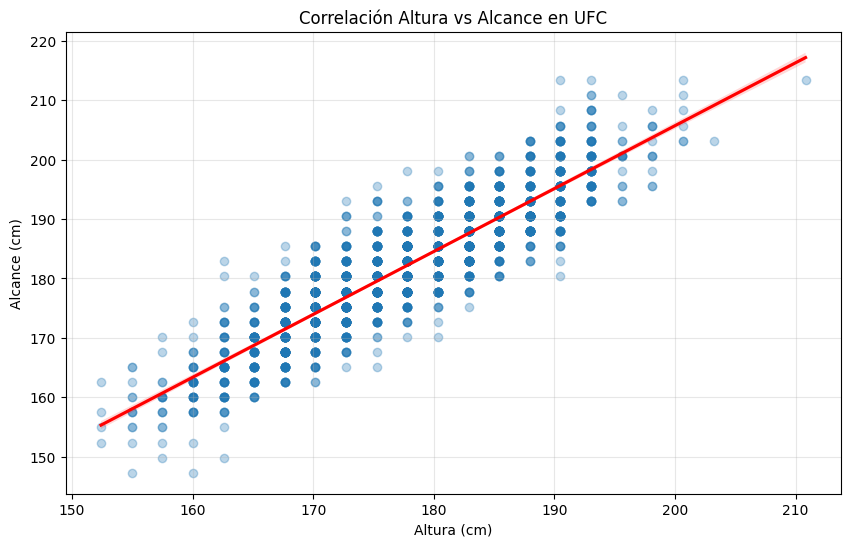

In [12]:
plt.figure(figsize=(10, 6))

sns.regplot(x='height', y='reach', data=df_peleadores_limpio,
            scatter_kws={'alpha':0.3},
            line_kws={'color':'red'})

plt.title('Correlación Altura vs Alcance en UFC')
plt.xlabel('Altura (cm)')
plt.ylabel('Alcance (cm)')
plt.grid(True, alpha=0.3)
plt.show()

Viendo que hay una correlación tan estrecha vamos a llenar los datos nulos de alcance con la correlación que tiene con la altura.

In [13]:
df_peleadores_alcance_altura = df_peleadores_limpio[df_peleadores_limpio['reach'].notnull() & df_peleadores_limpio['height'].notnull()]
df_peleadores_alcance_altura.head(20)

#Calculamos la correlación entre el alcance y la altura
correlacion_alcance_altura = df_peleadores_alcance_altura['reach'].sum() / df_peleadores_alcance_altura['height'].sum()
print(f"La relación promedio entre alcance y altura es: {correlacion_alcance_altura:.4f}")
#ahora cogemos las filas que tienen el alcance nulo y
alcance_altura_reparar = df_peleadores_limpio['reach'].isnull() & df_peleadores_limpio['height'].notnull()
#llenamos los datos vacios con la correlación altura alcance
df_peleadores_limpio.loc[alcance_altura_reparar, 'reach'] = df_peleadores_limpio.loc[alcance_altura_reparar, 'height'] * correlacion_alcance_altura


La relación promedio entre alcance y altura es: 1.0248


Ahora hacemos lo mismo pero con rellanando el campo height en lugar de reach

In [14]:
# Identificamos las filas que tienen 'reach' pero no tienen 'height'
mascara_rellenar_altura = df_peleadores_limpio['height'].isnull() & df_peleadores_limpio['reach'].notnull()

# Rellenamos los valores nulos de 'height' usando la 'reach' y la relación promedio
df_peleadores_limpio.loc[mascara_rellenar_altura, 'height'] = df_peleadores_limpio.loc[mascara_rellenar_altura, 'reach'] / mascara_rellenar_altura

# Verificamos si aún quedan valores nulos en 'height' después de rellenar
print("\nNúmero de valores nulos en 'height' después de rellenar:", df_peleadores_limpio['height'].isnull().sum())
print("Filas donde 'height' es nulo y 'reach' no es nulo después de rellenar:")
display(df_peleadores_limpio[df_peleadores_limpio['height'].isnull() & df_peleadores_limpio['reach'].notnull()])


Número de valores nulos en 'height' después de rellenar: 0
Filas donde 'height' es nulo y 'reach' no es nulo después de rellenar:


,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,...,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg,dob_datetime,dob_ordinal


In [15]:
df_peleadores_limpio[df_peleadores_limpio['reach'].isnull()]

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,...,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg,dob_datetime,dob_ordinal


In [16]:
df_peleadores_limpio = df_peleadores_limpio.copy()
df_peleadores_limpio['strike_efficiency_ratio'] = df_peleadores_limpio['splm'] / df_peleadores_limpio['sapm']
display(df_peleadores_limpio[['name', 'splm', 'sapm', 'strike_efficiency_ratio']].head())

,name,splm,sapm,strike_efficiency_ratio
0,Jessica Aguilar,4.93,7.19,0.685675
1,Deron Winn,4.55,6.21,0.732689
2,Gegard Mousasi,3.75,1.21,3.099174
3,Mike Pierce,2.62,2.36,1.110169
4,Hyun Gyu Lim,4.45,5.07,0.877712


In [17]:
df_peleadores_limpio_copy = df_peleadores_limpio.copy()
# Calculamos el ratio de victorias
df_peleadores_limpio_copy['win_ratio'] = df_peleadores_limpio_copy['wins'] / (df_peleadores_limpio_copy['wins'] + df_peleadores_limpio_copy['losses'])

# Manejamos los casos donde el peleador no tiene peleas (para evitar NaN en win_ratio si wins+losses=0)
df_peleadores_limpio_copy['win_ratio'] = df_peleadores_limpio_copy['win_ratio'].fillna(0)

display(df_peleadores_limpio_copy[['name', 'wins', 'losses', 'win_ratio', 'strike_efficiency_ratio']].head())

df_peleadores_limpio = df_peleadores_limpio_copy #actualiazmos el dataset original

,name,wins,losses,win_ratio,strike_efficiency_ratio
0,Jessica Aguilar,20,8,0.714286,0.685675
1,Deron Winn,7,3,0.700000,0.732689
2,Gegard Mousasi,42,6,0.875000,3.099174
3,Mike Pierce,17,7,0.708333,1.110169
4,Hyun Gyu Lim,13,7,0.650000,0.877712


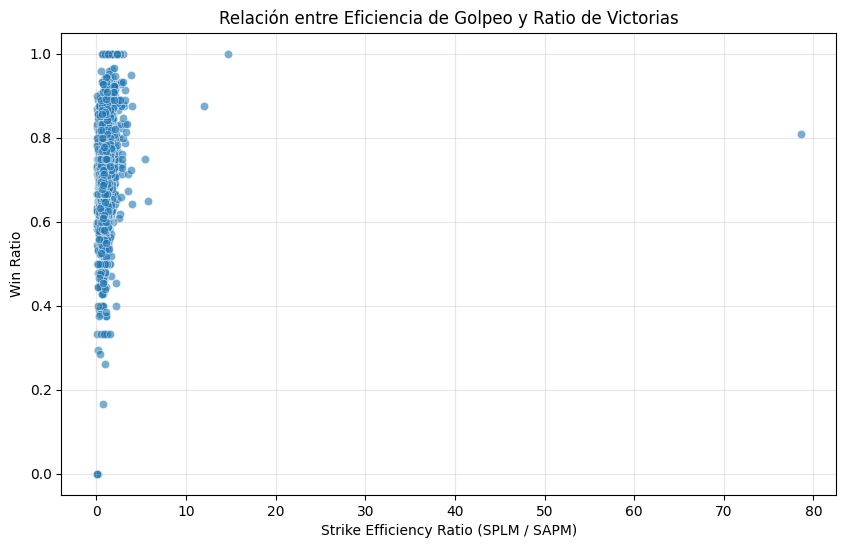

Correlación entre Strike Efficiency Ratio y Win Ratio: 0.1193


In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='strike_efficiency_ratio', y='win_ratio', data=df_peleadores_limpio, alpha=0.6)
plt.title('Relación entre Eficiencia de Golpeo y Ratio de Victorias')
plt.xlabel('Strike Efficiency Ratio (SPLM / SAPM)')
plt.ylabel('Win Ratio')
plt.grid(True, alpha=0.3)
plt.show()

# También podemos calcular la correlación numérica
correlation = df_peleadores_limpio['strike_efficiency_ratio'].corr(df_peleadores_limpio['win_ratio'])
print(f"Correlación entre Strike Efficiency Ratio y Win Ratio: {correlation:.4f}")

### Identificación de Outliers usando la regla de las 3-sigma en 'strike_efficiency_ratio'

In [19]:
# Calcular la media y la desviación estándar de 'strike_efficiency_ratio'
mean_strike_efficiency = df_peleadores_limpio['strike_efficiency_ratio'].mean()
std_strike_efficiency = df_peleadores_limpio['strike_efficiency_ratio'].std()

# Definir los límites de 3-sigma
upper_bound = mean_strike_efficiency + (3 * std_strike_efficiency)
lower_bound = mean_strike_efficiency - (3 * std_strike_efficiency)

print(f"Media de Strike Efficiency Ratio: {mean_strike_efficiency:.2f}")
print(f"Desviación Estándar de Strike Efficiency Ratio: {std_strike_efficiency:.2f}")
print(f"Límite Superior (Media + 3*Std): {upper_bound:.2f}")
print(f"Límite Inferior (Media - 3*Std): {lower_bound:.2f}")

# Identificar a los peleadores que son outliers
outliers_3sigma = df_peleadores_limpio[
    (df_peleadores_limpio['strike_efficiency_ratio'] > upper_bound) |
    (df_peleadores_limpio['strike_efficiency_ratio'] < lower_bound)
]

print(f"\nNúmero de peleadores identificados como outliers (3-sigma): {len(outliers_3sigma)}")
print("\nPeleadores Outliers (valores SPLM y SAPM para revisión):")
display(outliers_3sigma[['name', 'splm', 'sapm', 'strike_efficiency_ratio', 'win_ratio','wins','losses']])

Media de Strike Efficiency Ratio: 1.01
Desviación Estándar de Strike Efficiency Ratio: 1.69
Límite Superior (Media + 3*Std): 6.09
Límite Inferior (Media - 3*Std): -4.07

Número de peleadores identificados como outliers (3-sigma): 3

Peleadores Outliers (valores SPLM y SAPM para revisión):


,name,splm,sapm,strike_efficiency_ratio,win_ratio,wins,losses
377,Abdul-Kerim Edilov,10.22,0.13,78.615385,0.809524,17,4
1153,Khalid Murtazaliev,4.80,0.40,12.000000,0.875000,14,2
2586,Tom Murphy,2.50,0.17,14.705882,1.000000,8,0


He buscado el nombre de los 3 peleadores y son 3 outliers porque simplemente solo tienen 1 pelea dentro de la UFC el record es de otras compañias.

In [20]:
nombres_outliers = outliers_3sigma['name'].tolist()
print("Nombres de los peleadores identificados como outliers:")
print(nombres_outliers)

Nombres de los peleadores identificados como outliers:
['Abdul-Kerim Edilov', 'Khalid Murtazaliev', 'Tom Murphy']


In [21]:
#Printeamos el nombre de los luchadores y las peleas que tienen en la UFC
lucha_conteo = {}
for fighter_name in nombres_outliers:
    red_fighter_count = df_general[df_general['r_name'] == fighter_name].shape[0]
    blue_fighter_count = df_general[df_general['b_name'] == fighter_name].shape[0]
    total_fights = red_fighter_count + blue_fighter_count
    lucha_conteo[fighter_name] = total_fights

print("Conteo de peleas para cada peleador outlier:")
for fighter, count in lucha_conteo.items():
    print(f"- {fighter}: {count} peleas")

Conteo de peleas para cada peleador outlier:
- Abdul-Kerim Edilov: 1 peleas
- Khalid Murtazaliev: 1 peleas
- Tom Murphy: 1 peleas


In [22]:
print("Columns in df_general:", df_general.columns.tolist())
print("Columns in df_peleas:", df_peleas.columns.tolist())

lucha_conteo = {}

# Asumiendo que R_fighter y B_fighter están en df_peleas basándose en su descripción
# Si df_general fuera la intención, esto requeriría una fusión o un dataset diferente.
# Por ahora, procedemos con df_peleas ya que es el lugar más lógico para estos datos.

# Verificar si las columnas 'r_name' y 'b_name' existen en df_peleas antes de continuar
if 'r_name' in df_peleas.columns and 'b_name' in df_peleas.columns:
    for fighter_name in nombres_outliers:
        red_fighter_count = df_peleas[df_peleas['r_name'] == fighter_name].shape[0]
        blue_fighter_count = df_peleas[df_peleas['b_name'] == fighter_name].shape[0]
        total_fights = red_fighter_count + blue_fighter_count
        lucha_conteo[fighter_name] = total_fights

    print("Conteo de peleas para cada peleador outlier (usando df_peleas):")
    for fighter, count in lucha_conteo.items():
        print(f"- {fighter}: {count} peleas")
else:
    print("Error: Las columnas 'r_name' o 'b_name' no se encontraron en df_peleas. Por favor, revisa el esquema del DataFrame.")


Columns in df_general: ['event_id', 'event_name', 'date', 'location', 'fight_id', 'division', 'title_fight', 'method', 'finish_round', 'match_time_sec', 'total_rounds', 'referee', 'r_name', 'r_id', 'r_kd', 'r_sig_str_landed', 'r_sig_str_atmpted', 'r_sig_str_acc', 'r_total_str_landed', 'r_total_str_atmpted', 'r_total_str_acc', 'r_td_landed', 'r_td_atmpted', 'r_td_acc', 'r_sub_att', 'r_ctrl', 'r_head_landed', 'r_head_atmpted', 'r_head_acc', 'r_body_landed', 'r_body_atmpted', 'r_body_acc', 'r_leg_landed', 'r_leg_atmpted', 'r_leg_acc', 'r_dist_landed', 'r_dist_atmpted', 'r_dist_acc', 'r_clinch_landed', 'r_clinch_atmpted', 'r_clinch_acc', 'r_ground_landed', 'r_ground_atmpted', 'r_ground_acc', 'r_landed_head_per', 'r_landed_body_per', 'r_landed_leg_per', 'r_landed_dist_per', 'r_landed_clinch_per', 'r_landed_ground_per', 'r_nick_name', 'r_wins', 'r_losses', 'r_draws', 'r_height', 'r_weight', 'r_reach', 'r_stance', 'r_dob', 'r_splm', 'r_str_acc', 'r_sapm', 'r_str_def', 'r_td_avg', 'r_td_avg_ac

In [23]:
lucha_conteo = {}

# Correcting column names to 'r_name' and 'b_name' based on inspection
if 'r_name' in df_peleas.columns and 'b_name' in df_peleas.columns:
    for fighter_name in nombres_outliers:
        red_fighter_count = df_peleas[df_peleas['r_name'] == fighter_name].shape[0]
        blue_fighter_count = df_peleas[df_peleas['b_name'] == fighter_name].shape[0]
        total_fights = red_fighter_count + blue_fighter_count
        lucha_conteo[fighter_name] = total_fights

    print("Conteo de peleas para cada peleador outlier (usando df_peleas):")
    for fighter, count in lucha_conteo.items():
        print(f"- {fighter}: {count} peleas")
else:
    print("Error: 'r_name' or 'b_name' columns not found in df_peleas. Please check the DataFrame schema.")

Conteo de peleas para cada peleador outlier (usando df_peleas):
- Abdul-Kerim Edilov: 1 peleas
- Khalid Murtazaliev: 1 peleas
- Tom Murphy: 1 peleas


### Ponderación de `strike_efficiency_ratio` por el número de peleas

Vamos a crear una métrica ponderada que refleje la confianza en el `strike_efficiency_ratio` en función del número de peleas del peleador. Una forma sencilla es multiplicar el `strike_efficiency_ratio` por el número de peleas, o crear una media móvil si tuviéramos datos de peleas individuales a lo largo del tiempo. Sin embargo, dado que tenemos un conteo total de peleas para cada outlier, podemos ajustar la métrica de eficiencia.

Para este ejemplo, asumiremos que queremos 'reducir' el valor de los outliers, o al menos darles menos peso. Podríamos usar una ponderación simple que le dé más peso a los peleadores con más peleas. Para los outliers con solo 1 pelea, su `strike_efficiency_ratio` podría considerarse menos representativo. Una forma es definir un umbral mínimo de peleas para considerar una estadística como 'estable' y ajustar las que están por debajo.

In [24]:
# Primero, asegurémonos de que df_peleadores_limpio tenga el conteo de peleas para los outliers.
# Como ya tenemos el 'lucha_conteo' de los outliers, podemos mapear esto de vuelta al DataFrame original

# Creamos una columna temporal para el conteo de peleas en df_peleadores_limpio
# Necesitamos obtener el conteo de peleas para *todos* los peleadores, no solo los outliers.
# Para simplificar, y dado que ya hemos visto que los outliers tienen 1 pelea, podemos crear una columna 'total_fights' en df_peleadores_limpio.

# Vamos a recrear un conteo de peleas más general para todos los peleadores en df_peleadores_limpio
# Crearemos un diccionario de conteo de peleas para todos los peleadores presentes en df_peleas
all_fighters_fight_count = {}
for index, row in df_peleas.iterrows():
    r_name = row['r_name']
    b_name = row['b_name']
    all_fighters_fight_count[r_name] = all_fighters_fight_count.get(r_name, 0) + 1
    all_fighters_fight_count[b_name] = all_fighters_fight_count.get(b_name, 0) + 1

# Mapeamos este conteo de peleas a df_peleadores_limpio
df_peleadores_limpio['total_fights'] = df_peleadores_limpio['name'].map(all_fighters_fight_count).fillna(0).astype(int)

# Ahora, vamos a crear un 'weighted_strike_efficiency_ratio'
# Una forma simple es usar el número de peleas para 'suavizar' la eficiencia.
# Por ejemplo, podemos usar una media ponderada que dé más peso a los peleadores con más peleas.
# O, para los que tienen muy pocas peleas, podemos reemplazar su ratio con la media del grupo o un valor más conservador.

# Opción 1: Simplemente ignorar los outliers con pocas peleas para ciertos análisis.
# Opción 2: Aplicar una ponderación.

# Ejemplo de ponderación: (strike_efficiency_ratio * total_fights) / (total_fights + constante_suavizada)
# La 'constante_suavizada' ayuda a que los peleadores con pocas peleas no tengan un peso demasiado bajo si total_fights es 0 o 1.
# Si un peleador tiene 0 peleas, total_fights será 0, lo que ya hemos manejado.

# Vamos a aplicar una lógica donde si tienen muy pocas peleas (e.g., < 2), su ratio ponderado sea la media general
# para evitar que un solo resultado extremo distorsione.

mean_strike_efficiency = df_peleadores_limpio['strike_efficiency_ratio'].mean()

df_peleadores_limpio['weighted_strike_efficiency_ratio'] = df_peleadores_limpio.apply(
    lambda row: row['strike_efficiency_ratio'] if row['total_fights'] >= 2
                else mean_strike_efficiency, axis=1
)


print("Datos para los peleadores outlier después de la ponderación:")
display(df_peleadores_limpio[df_peleadores_limpio['name'].isin(nombres_outliers)][['name','wins','draws','losses' ,'total_fights', 'strike_efficiency_ratio', 'weighted_strike_efficiency_ratio']])

print("\nEjemplo de peleadores no outliers para comparación:")
display(df_peleadores_limpio[~df_peleadores_limpio['name'].isin(nombres_outliers)].head()[['name', 'total_fights', 'strike_efficiency_ratio', 'weighted_strike_efficiency_ratio']])

Datos para los peleadores outlier después de la ponderación:


,name,wins,draws,losses,total_fights,strike_efficiency_ratio,weighted_strike_efficiency_ratio
377,Abdul-Kerim Edilov,17,0,4,1,78.615385,1.012144
1153,Khalid Murtazaliev,14,0,2,1,12.000000,1.012144
2586,Tom Murphy,8,0,0,1,14.705882,1.012144



Ejemplo de peleadores no outliers para comparación:


,name,total_fights,strike_efficiency_ratio,weighted_strike_efficiency_ratio
0,Jessica Aguilar,5,0.685675,0.685675
1,Deron Winn,5,0.732689,0.732689
2,Gegard Mousasi,12,3.099174,3.099174
3,Mike Pierce,14,1.110169,1.110169
4,Hyun Gyu Lim,7,0.877712,0.877712


Por cierto si ves que los total_fights y el número de victorias y derrotas es mayor es porque el campo total_fights tiene solo en cuenta las peleas en la UFC y no en la otras compañias antes de llegar a la UFC ya que las demás compañias no tienen estos datos.

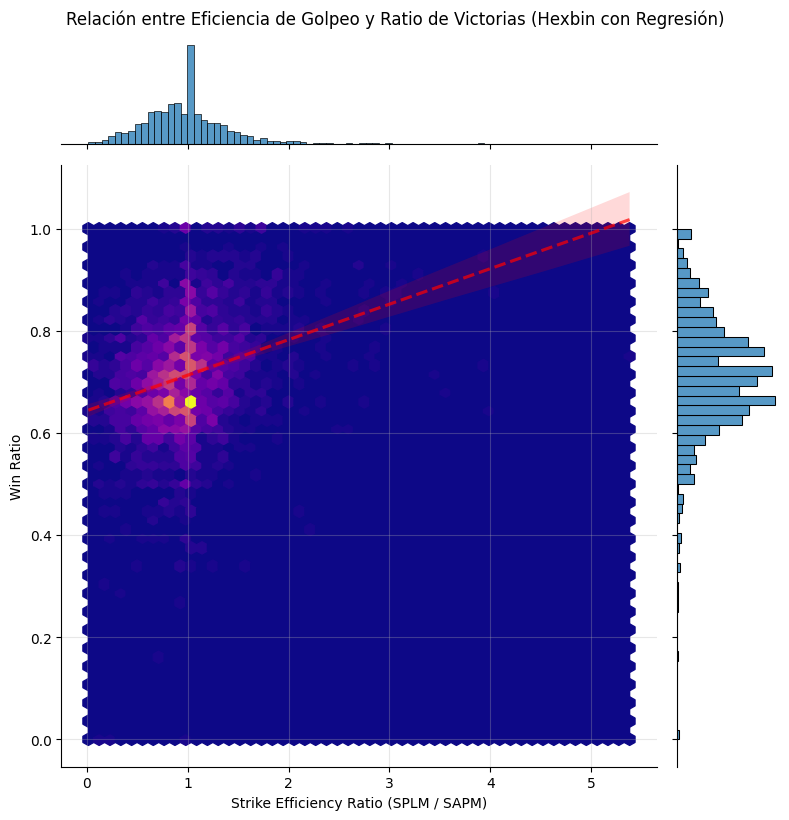

Correlación entre Weighted Strike Efficiency Ratio y Win Ratio: 0.2795


In [25]:
#Creación de una grafica hexagonal
g = sns.jointplot(x='weighted_strike_efficiency_ratio', y='win_ratio', data=df_peleadores_limpio, kind='hex', height=8, cmap='plasma')
sns.regplot(x='weighted_strike_efficiency_ratio', y='win_ratio', data=df_peleadores_limpio, ax=g.ax_joint, scatter=False, color='red', line_kws={'linestyle':'--', 'alpha':0.7})
g.fig.suptitle('Relación entre Eficiencia de Golpeo y Ratio de Victorias (Hexbin con Regresión)', y=1.02)
g.set_axis_labels('Strike Efficiency Ratio (SPLM / SAPM)', 'Win Ratio')
g.ax_joint.grid(True, alpha=0.3)
plt.show()

# También podemos calcular la correlación numérica
correlation = df_peleadores_limpio['weighted_strike_efficiency_ratio'].corr(df_peleadores_limpio['win_ratio'])
print(f"Correlación entre Weighted Strike Efficiency Ratio y Win Ratio: {correlation:.4f}")

## Dataset General

Tengo un pequeño problema y es que en el dataframe general el cual usaremos para entrenar el modelo para predecir peleas, hay una fuga de datos debido a que en la columna Wins de cada peleador y la columna losses tiene sumada la victoria o derrota de la pelea que acaba de ocurrir por lo tanto restaremos 1 victoria o derrota para evitar la fuga de datos.

In [26]:
# Crear una copia del DataFrame para trabajar con ella, para preservar el df_general original
df_general_pre_fight = df_general.copy()

# Asegurar que las columnas relevantes sean numéricas. Coercionar errores a NaN y rellenar con 0 antes de convertir a int
# Esto maneja cualquier valor no numérico de forma elegante.
for col in ['r_wins', 'r_losses', 'r_draws', 'b_wins', 'b_losses', 'b_draws']:
    df_general_pre_fight[col] = pd.to_numeric(df_general_pre_fight[col], errors='coerce').fillna(0).astype(int)

# Ajustar los registros basándose en el resultado de la pelea
# Caso 1: El peleador rojo gana
mask_r_wins = df_general_pre_fight['winner_id'] == df_general_pre_fight['r_id']
df_general_pre_fight.loc[mask_r_wins, 'r_wins'] -= 1
df_general_pre_fight.loc[mask_r_wins, 'b_losses'] -= 1

# Caso 2: El peleador azul gana
mask_b_wins = df_general_pre_fight['winner_id'] == df_general_pre_fight['b_id']
df_general_pre_fight.loc[mask_b_wins, 'b_wins'] -= 1
df_general_pre_fight.loc[mask_b_wins, 'r_losses'] -= 1

# Caso 3: Empates (asumiendo que winner_id es nulo o un método específico indica un empate)
# Consideraremos las filas donde winner_id es NaN O el método contiene 'draw' (sin distinción de mayúsculas/minúsculas) como un empate.
# Nota: Los empates en UFC son raros, pero esto maneja la posibilidad.
mask_draw = (df_general_pre_fight['winner_id'].isnull()) | \
            (df_general_pre_fight['method'].str.contains('draw', case=False, na=False))

df_general_pre_fight.loc[mask_draw, 'r_draws'] -= 1
df_general_pre_fight.loc[mask_draw, 'b_draws'] -= 1

# Mostrar las primeras filas con las estadísticas pre-pelea ajustadas para verificación
print("DataFrame con registros pre-pelea ajustados (primeras 5 filas):")
display(df_general_pre_fight[['r_name', 'r_wins', 'r_losses', 'r_draws', 'b_name', 'b_wins', 'b_losses', 'b_draws', 'winner_id', 'method']].head())

DataFrame con registros pre-pelea ajustados (primeras 5 filas):


,r_name,r_wins,r_losses,r_draws,b_name,b_wins,b_losses,b_draws,winner_id,method
0,Benoit Saint Denis,14,3,0,Mauricio Ruffy,12,1,0,c2299ec916bc7c56,Submission
1,Nassourdine Imavov,16,4,0,Caio Borralho,17,1,0,881bf86d4cba8578,Decision - Unanimous
2,Modestas Bukauskas,18,6,0,Paul Craig,17,9,1,476fe566d2df676e,KO/TKO
3,Bolaji Oki,10,2,0,Mason Jones,16,2,0,f6ad6a1e4d600e0d,KO/TKO
4,Axel Sola,10,0,1,Rhys McKee,14,6,1,1d2d98ddd05b38fb,KO/TKO


In [27]:
# 1. Para ver TODAS las columnas (horizontal)
pd.set_option('display.max_columns', None)

# 2. Para ver TODAS las filas (vertical)
pd.set_option('display.max_rows', None)

null_counts = df_general_pre_fight.isnull().sum()
null_counts_desc = null_counts.sort_values(ascending=False)

# Expande la lista hasta donde quiera
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(null_counts_desc[null_counts_desc > 0])

,0
b_ground_acc,3816
b_td_acc,3126
r_ground_acc,2956
r_td_acc,2686
b_nick_name,2388
r_nick_name,2328
b_clinch_acc,2042
r_clinch_acc,2003
r_leg_acc,1584
b_leg_acc,1568


podemos ver que 53 columnas de las 84 con valores nulos tienen 21 nulos exactos probablemente sean  peleas que hayan sido detenidas o de las primeras peleas de la UFC así que vamos a ver.

In [28]:
# Vamos a mirar las filas donde 'r_total_str_landed' es nulo
# (Usamos esta columna como "canario en la mina")
ghost_fights = df_general_pre_fight[df_general_pre_fight['r_total_str_landed'].isnull()]

print(f"Número de peleas fantasma encontradas: {len(ghost_fights)}")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):

  # Miremos qué tienen de raro (probablemente falten nombres, fechas o resultados)
  display(ghost_fights[['r_name', 'b_name', 'winner_id', 'date', 'event_id']].head(10))

Número de peleas fantasma encontradas: 21


,r_name,b_name,winner_id,date,event_id
8165,Cesar Marscucci,Paulo Santos,e8efeb9cf33b1941,1998/10/16,32a3025d5db456ae
8171,Andre Roberts,Harry Moskowitz,a54a35a670d8e852,1998/05/15,4a01dc8376736ef5
8187,Chris Brennan,Courtney Turner,b19fc66613dc75b9,1998/03/13,749685d24e2cac50
8188,Laverne Clark,Josh Stuart,1c2f2571b18791b6,1998/03/13,749685d24e2cac50
8221,Justin Martin,Eric Martin,3da19339ee7051d5,1997/02/07,96eff1a628adcc7f
8222,Nick Sanzo,Jackie Lee,1d147d4163a6989b,1997/02/07,96eff1a628adcc7f
8230,Tai Bowden,Jack Nilson,2efbc83a6b9b7f86,1996/12/07,9b5b5a75523728f3
8231,Steve Nelmark,Marcus Bossett,13e62d766b709aa6,1996/12/07,9b5b5a75523728f3
8232,Mark Hall,Felix Lee Mitchell,18524b46c570730b,1996/12/07,9b5b5a75523728f3
8238,Scott Ferrozzo,Sam Fulton,977081bc01197656,1996/09/20,6ceff86fae4f6b3b


vamos a eliminarlas debido a que son las primeras peleas que hubo en la UFC y no hay datos sobre ellas ya que datan del 1995-1999.

In [29]:
# Identificar y rellenar 'r_height' nulos donde 'r_reach' no es nulo
mask_r_height_null = df_general_pre_fight['r_height'].isnull() & df_general_pre_fight['r_reach'].notnull()
df_general_pre_fight.loc[mask_r_height_null, 'r_height'] = df_general_pre_fight.loc[mask_r_height_null, 'r_reach'] / correlacion_alcance_altura

# Identificar y rellenar 'b_height' nulos donde 'b_reach' no es nulo
mask_b_height_null = df_general_pre_fight['b_height'].isnull() & df_general_pre_fight['b_reach'].notnull()
df_general_pre_fight.loc[mask_b_height_null, 'b_height'] = df_general_pre_fight.loc[mask_b_height_null, 'b_reach'] / correlacion_alcance_altura

print("Valores nulos en 'r_height' después de la imputación inicial:", df_general_pre_fight['r_height'].isnull().sum())
print("Valores nulos en 'b_height' después de la imputación inicial:", df_general_pre_fight['b_height'].isnull().sum())

Valores nulos en 'r_height' después de la imputación inicial: 5
Valores nulos en 'b_height' después de la imputación inicial: 19


In [30]:
# Identificar y rellenar 'r_reach' nulos donde 'r_height' no es nulo
mask_r_reach_null = df_general_pre_fight['r_reach'].isnull() & df_general_pre_fight['r_height'].notnull()
df_general_pre_fight.loc[mask_r_reach_null, 'r_reach'] = df_general_pre_fight.loc[mask_r_reach_null, 'r_height'] * correlacion_alcance_altura

# Identificar y rellenar 'b_reach' nulos donde 'b_height' no es nulo
mask_b_reach_null = df_general_pre_fight['b_reach'].isnull() & df_general_pre_fight['b_height'].notnull()
df_general_pre_fight.loc[mask_b_reach_null, 'b_reach'] = df_general_pre_fight.loc[mask_b_reach_null, 'b_height'] * correlacion_alcance_altura

print("Valores nulos en 'r_reach' después de la imputación:", df_general_pre_fight['r_reach'].isnull().sum())
print("Valores nulos en 'b_reach' después de la imputación:", df_general_pre_fight['b_reach'].isnull().sum())

Valores nulos en 'r_reach' después de la imputación: 5
Valores nulos en 'b_reach' después de la imputación: 19


In [31]:
# 1. Hacemos una copia de seguridad para trabajar
df = df_general_pre_fight.copy()

print("🧹 1. Limpiando y agrupando las divisiones...")

# 2. Definimos las divisiones base
divisiones_base = [
    "women's strawweight", "women's flyweight", "women's bantamweight", "women's featherweight",
    "strawweight", "flyweight", "bantamweight", "featherweight", "lightweight",
    "welterweight", "middleweight", "light heavyweight", "heavyweight",
    "super heavyweight", "catch weight", "open weight"
]

# 3. Función de mapeo
def limpiar_division(texto):
    if pd.isna(texto):
        return "catch weight"
    texto = str(texto).lower()
    for div in divisiones_base:
        if div in texto:
            # Evitar que "women's bantamweight" se asigne a "bantamweight" normal
            if "women's" not in div and "women" in texto:
                continue
            return div
    # Todo lo que no encaje (torneos raros) va a catch weight temporalmente
    return "catch weight"

# 4. CREAMOS LA COLUMNA (Esto soluciona tu KeyError)
df['division_limpia'] = df['division'].apply(limpiar_division)

print("✂️ 2. Eliminando peleas no estandarizadas (Catch/Open Weight)...")

# 5. Definimos las únicas divisiones que consideramos "Válidas y Modernas"
divisiones_validas = [
    "women's strawweight", "women's flyweight", "women's bantamweight", "women's featherweight",
    "flyweight", "bantamweight", "featherweight", "lightweight",
    "welterweight", "middleweight", "light heavyweight", "heavyweight"
]

# 6. FILTRAMOS el dataset para quedarnos solo con lo bueno
filas_antes = len(df)
df = df[df['division_limpia'].isin(divisiones_validas)].copy()
filas_despues = len(df)

print(f"   -> Se han eliminado {filas_antes - filas_despues} peleas.")

# 7. (Opcional pero recomendado) Reemplazamos la columna 'division' original por la limpia
df['division'] = df['division_limpia']
df = df.drop(columns=['division_limpia'])

# 8. Guardamos los cambios en tu variable principal
df_general_pre_fight = df

print("✅ ¡Dataset de UFC Moderno listo! Divisiones perfectamente categorizadas.")

# Comprobación final: Mostrar las divisiones que te han quedado
display(df_general_pre_fight['division'].value_counts())

🧹 1. Limpiando y agrupando las divisiones...
✂️ 2. Eliminando peleas no estandarizadas (Catch/Open Weight)...
   -> Se han eliminado 189 peleas.
✅ ¡Dataset de UFC Moderno listo! Divisiones perfectamente categorizadas.


,count
division,
lightweight,1407
welterweight,1357
middleweight,1097
featherweight,818
heavyweight,744
bantamweight,739
light heavyweight,733
flyweight,387
women's strawweight,347


In [32]:
# Trabajamos sobre tu dataframe principal
df = df_general_pre_fight.copy()

print("📏 1. Reparando estaturas (Height) con la media de cada división...")

# Rellenamos r_height usando la media de su división
df['r_height'] = df['r_height'].fillna(
    df.groupby('division')['r_height'].transform('mean')
)

# Rellenamos b_height usando la media de su división
df['b_height'] = df['b_height'].fillna(
    df.groupby('division')['b_height'].transform('mean')
)

print(f"🦍 2. Reparando alcances (Reach) usando el Ape Index ({correlacion_alcance_altura:.4f})...")

# Aplicamos tu lógica de correlación a la esquina Roja (Red)
r_reach_nulos = df['r_reach'].isnull() & df['r_height'].notnull()
df.loc[r_reach_nulos, 'r_reach'] = df.loc[r_reach_nulos, 'r_height'] * correlacion_alcance_altura

# Aplicamos tu lógica de correlación a la esquina Azul (Blue)
b_reach_nulos = df['b_reach'].isnull() & df['b_height'].notnull()
df.loc[b_reach_nulos, 'b_reach'] = df.loc[b_reach_nulos, 'b_height'] * correlacion_alcance_altura

# --- VERIFICACIÓN FINAL ---
cols_revisar = ['r_height', 'b_height', 'r_reach', 'b_reach']
nulos_restantes = df[cols_revisar].isnull().sum()

print("\n📊 Nulos restantes después de la imputación:")
print(nulos_restantes)

# Guardamos los cambios
df_general_pre_fight = df

📏 1. Reparando estaturas (Height) con la media de cada división...
🦍 2. Reparando alcances (Reach) usando el Ape Index (1.0248)...

📊 Nulos restantes después de la imputación:
r_height    0
b_height    0
r_reach     0
b_reach     0
dtype: int64


In [33]:
# 1. BORRADO QUIRÚRGICO
# Eliminamos las filas donde no hay datos de golpes (la columna 'r_total_str_landed' es nula)
df_general_pre_fight = df_general_pre_fight.dropna(subset=['r_total_str_landed'])

print(f"🗑️ Eliminadas {len(df_general_pre_fight) - len(df_general_pre_fight)} peleas antiguas sin estadísticas.")
'''
# 2. RELLENO DE DATOS FÍSICOS (Para los pocos nulos que queden en height/weight)
# Usamos la mediana porque es más resistente a datos raros que la media
cols_fisicas = ['r_height', 'r_weight', 'b_height', 'b_weight']

for col in cols_fisicas:
    if col in df_general_pre_fight.columns:
        # Rellenamos solo los huecos vacíos con la mediana de esa columna
        mediana = df_general_pre_fight[col].median()
        df_general_pre_fight[col] = df_general_pre_fight[col].fillna(mediana)
'''
# 3. VERIFICACIÓN FINAL
print(f"✅ Nulos restantes en el dataset limpio: {df_general_pre_fight.isnull().sum().sum()}")

🗑️ Eliminadas 0 peleas antiguas sin estadísticas.
✅ Nulos restantes en el dataset limpio: 26369


In [34]:
null_counts = df_general_pre_fight.isnull().sum()
null_counts_desc = null_counts.sort_values(ascending=False)
display(null_counts_desc[null_counts_desc > 0])

,0
b_ground_acc,3696
b_td_acc,3015
r_ground_acc,2883
r_td_acc,2613
b_nick_name,2287
r_nick_name,2261
b_clinch_acc,1943
r_clinch_acc,1906
r_leg_acc,1490
b_leg_acc,1475


### Normaliazción de ciertos valores
La mayoria de datos que faltan son acc que significa accuracy eso se calcula simplemente con

Accuracy=Golpes Lanzados (Attempted)/Golpes Conectados (Landed)

y luego haremos una normalización de los datos que pasaran de ir de 0-100 a 0-1​

In [35]:
# Trabajamos sobre tu dataframe
df = df_general_pre_fight

# Lista de métricas
metrics = ['ground', 'td', 'clinch', 'leg', 'body', 'head', 'dist', 'sig_str', 'total_str']
sides = ['r', 'b']

print("🔧 Recalculando Accuracies (Asegurando escala 0-1)...")

for side in sides:
    for metric in metrics:
        acc_col = f"{side}_{metric}_acc"
        land_col = f"{side}_{metric}_landed"
        att_col = f"{side}_{metric}_atmpted"

        if acc_col in df.columns and land_col in df.columns and att_col in df.columns:

            # 1. CALCULAMOS EN FORMATO 0-100 (Para coincidir con tus originales)
            # Multiplicamos por 100 para que sea igual que tus datos actuales (ej: 50.0)
            calculated_acc = (df[land_col] / df[att_col]) * 100

            # 2. RELLENAMOS LOS HUECOS
            df[acc_col] = df[acc_col].fillna(calculated_acc)

            # 3. CORRECCIÓN DE CEROS (Si intentos es 0, precisión es 0)
            mask_zero_attempts = df[att_col] == 0
            df.loc[mask_zero_attempts, acc_col] = df.loc[mask_zero_attempts, acc_col].fillna(0)

            # 4. PASO CRUCIAL: NORMALIZAR TODO A 0-1
            # Ahora mismo tienes todo mezclado o todo en 0-100.
            # Vamos a asegurarnos de que toda la columna esté en 0-1.

            # Si el máximo de la columna es mayor a 1, asumimos que está en porcentaje y dividimos
            if df[acc_col].max() > 1.0:
                df[acc_col] = df[acc_col] / 100.0

# REPARACIÓN DE ALCANCE (Igual que antes)
for side in ['r', 'b']:
    reach_col = f"{side}_reach"
    height_col = f"{side}_height"
    if reach_col in df.columns and height_col in df.columns:
        df[reach_col] = df[reach_col].fillna(df[height_col])

# --- VERIFICACIÓN FINAL ---
print("\n📊 Verificación de Rangos (Debe ser Min 0.0 - Max 1.0):")
acc_cols = [c for c in df.columns if '_acc' in c]
stats = df[acc_cols].describe().loc[['min', 'max', 'mean']]

# Comprobamos si queda algo mayor a 1
errores = 0
for col in acc_cols:
    if df[col].max() > 1.0:
        print(f"⚠️ {col} sigue teniendo valores > 1.0")
        errores += 1

if errores == 0:
    print("✅ ¡Perfecto! Todas las precisiones están estandarizadas entre 0 y 1.")

display(stats)

🔧 Recalculando Accuracies (Asegurando escala 0-1)...

📊 Verificación de Rangos (Debe ser Min 0.0 - Max 1.0):
⚠️ r_str_acc sigue teniendo valores > 1.0
⚠️ r_td_avg_acc sigue teniendo valores > 1.0
⚠️ b_str_acc sigue teniendo valores > 1.0
⚠️ b_td_avg_acc sigue teniendo valores > 1.0


,r_sig_str_acc,r_total_str_acc,r_td_acc,r_head_acc,r_body_acc,r_leg_acc,r_dist_acc,r_clinch_acc,r_ground_acc,r_str_acc,r_td_avg_acc,b_sig_str_acc,b_total_str_acc,b_td_acc,b_head_acc,b_body_acc,b_leg_acc,b_dist_acc,b_clinch_acc,b_ground_acc,b_str_acc,b_td_avg_acc
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,83.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,100.000000
mean,0.475278,0.552847,0.299662,0.39034,0.636227,0.666421,0.400946,0.528138,0.455405,44.838123,38.519283,0.434032,0.516636,0.226567,0.339263,0.603175,0.654257,0.375597,0.509031,0.375911,43.894375,36.044338


In [36]:
# Buscamos absolutamente todas las columnas que contengan 'acc' en su nombre
all_acc_cols = [c for c in df_general_pre_fight.columns if 'acc' in c.lower()]

print("🧹 Normalizando columnas rebeldes...")

for col in all_acc_cols:
    max_val = df_general_pre_fight[col].max()

    # Si detectamos que el máximo es mayor a 1, es que está en escala 0-100
    if max_val > 1.0:
        df_general_pre_fight[col] = df_general_pre_fight[col] / 100.0
        print(f"✅ {col} normalizada (Max era: {max_val})")

# Verificación final de los rebeldes
rebeldes = ['r_str_acc', 'r_td_avg_acc', 'b_str_acc', 'b_td_avg_acc']
display(df_general_pre_fight[rebeldes].describe().loc[['min', 'max']])

🧹 Normalizando columnas rebeldes...
✅ r_str_acc normalizada (Max era: 83)
✅ r_td_avg_acc normalizada (Max era: 100)
✅ b_str_acc normalizada (Max era: 100)
✅ b_td_avg_acc normalizada (Max era: 100)


,r_str_acc,r_td_avg_acc,b_str_acc,b_td_avg_acc
min,0.00,0.0,0.0,0.0
max,0.83,1.0,1.0,1.0


In [37]:
null_counts = df_general_pre_fight.isnull().sum()
null_counts_desc = null_counts.sort_values(ascending=False)
display(null_counts_desc[null_counts_desc > 0])

,0
b_nick_name,2287
r_nick_name,2261
winner_id,144
winner,144
b_dob,96
r_ctrl,82
b_ctrl,82
b_stance,41
referee,25
r_dob,24


Ahora terminaremos de limpiar los datos en este dataset primero eliminaremos las columnas irrelaventes después eliminaremos las filas que no tienen ganador rellenaremos datos técnicos como el contorl o la guardia con valores predeterminados.

In [38]:
# Trabajamos sobre tu dataframe
df = df_general_pre_fight

# --- 1. ELIMINAR COLUMNAS IRRELEVANTES (RUIDO) ---
# Los apodos y el árbitro no aportan valor matemático para predecir el ganador
cols_basura = ['r_nick_name', 'b_nick_name', 'referee']
# Solo borramos si existen (por si ejecutaste algo antes)
cols_a_borrar = [c for c in cols_basura if c in df.columns]

if cols_a_borrar:
    df = df.drop(columns=cols_a_borrar)
    print(f"🗑️ Columnas eliminadas (Ruido): {cols_a_borrar}")

# --- 2. ELIMINAR FILAS SIN GANADOR (TARGET) ---
# Si 'winner' o 'winner_id' es nulo, no podemos entrenar con esa pelea.
# Es fundamental borrar estas filas.
cols_target = ['winner', 'winner_id']
# Nos aseguramos de borrar filas si falta CUALQUIERA de los dos
df = df.dropna(subset=[c for c in cols_target if c in df.columns])
print("❌ Filas eliminadas sin resultado (No Contest/Empate técnico).")

# --- 3. RELLENAR DATOS TÉCNICOS (IMPUTACIÓN) ---

# A) Tiempo de Control (CTRL): Si falta, es que no hubo control (0 segundos)
for col in ['r_ctrl', 'b_ctrl']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"✅ {col} rellenado con 0.")

# B) Guardia (STANCE): Si falta, ponemos la más común ('Orthodox')
for col in ['r_stance', 'b_stance']:
    if col in df.columns:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f"✅ {col} rellenado con '{moda}'.")

# C) Rondas Totales: Si falta, asumimos pelea estándar de 3 asaltos
if 'total_rounds' in df.columns:
    df['total_rounds'] = df['total_rounds'].fillna(3)
    print("✅ total_rounds rellenado con 3.")

# --- 4. VERIFICACIÓN FINAL ---
print("\n---------------------------------------")
total_nulos = df.isnull().sum().sum()

if total_nulos == 0:
    print("🚀 ¡ENHORABUENA! Tu DataFrame tiene 0 nulos.")
    print(f"Tamaño final del dataset: {df.shape}")
else:
    print(f"⚠️ Aún quedan {total_nulos} nulos. Revisa:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

# Guardamos los cambios
df_general_pre_fight = df

🗑️ Columnas eliminadas (Ruido): ['r_nick_name', 'b_nick_name', 'referee']
❌ Filas eliminadas sin resultado (No Contest/Empate técnico).
✅ r_ctrl rellenado con 0.
✅ b_ctrl rellenado con 0.
✅ r_stance rellenado con 'Orthodox'.
✅ b_stance rellenado con 'Orthodox'.
✅ total_rounds rellenado con 3.

---------------------------------------
⚠️ Aún quedan 123 nulos. Revisa:
r_weight     1
r_dob       23
b_weight     5
b_dob       94
dtype: int64


llenaremos el peso de los peleadores poniendo el peso limite de la división ya que el 99% de los peleadores pelean en el limite de la división.

In [39]:
# Trabajamos sobre una copia de tu dataframe principal
df = df_general_pre_fight.copy()

print("⚖️ Rellenando pesos faltantes según la división...")

# 1. Rellenar la esquina ROJA (Red)
if 'r_weight' in df.columns:
    # Usamos transform('median') porque en los pesajes los valores suelen ser exactos
    # (ej: todos los pesos ligeros pesan exactamente 155 o 156 libras). La mediana es perfecta aquí.
    df['r_weight'] = df['r_weight'].fillna(
        df.groupby('division')['r_weight'].transform('median')
    )

# 2. Rellenar la esquina AZUL (Blue)
if 'b_weight' in df.columns:
    df['b_weight'] = df['b_weight'].fillna(
        df.groupby('division')['b_weight'].transform('median')
    )

# 3. VERIFICACIÓN FINAL
cols_peso = [col for col in ['r_weight', 'b_weight'] if col in df.columns]

if cols_peso:
    nulos_peso = df[cols_peso].isnull().sum()
    print("\n📊 Nulos restantes en las columnas de peso:")
    print(nulos_peso)

    if nulos_peso.sum() == 0:
        print("✅ ¡Perfecto! Todos los pesos han sido rellenados correctamente.")
else:
    print("⚠️ No se encontraron las columnas 'r_weight' o 'b_weight'. Verifica el nombre exacto.")

# Guardamos los cambios
df_general_pre_fight = df

⚖️ Rellenando pesos faltantes según la división...

📊 Nulos restantes en las columnas de peso:
r_weight    0
b_weight    0
dtype: int64
✅ ¡Perfecto! Todos los pesos han sido rellenados correctamente.


In [40]:
null_counts = df_eventos.isnull().sum()
null_counts_desc = null_counts.sort_values(ascending=False)
display(null_counts_desc[null_counts_desc > 0])

,0
winner,147
winner_id,147


In [41]:
df_general_pre_fight.head()

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_dob,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_dob,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,3.0,Benoit Saint Denis,c2299ec916bc7c56,0.0,17.0,38.0,0.44,37.0,61.0,0.61,3.0,10.0,0.30,1.0,278.0,9.0,26.0,0.35,8.0,12.0,0.67,0.0,0.0,0.00,9.0,26.0,0.35,3.0,3.0,1.00,5.0,9.0,0.56,52.0,47.0,0.0,52.0,17.0,29.0,14,3,0,180.34,70.31,185.42,Southpaw,1995/12/18,5.05,0.55,4.19,42,4.35,0.37,70,1.6,Mauricio Ruffy,9c393e836a852f30,0.0,5.0,17.0,0.29,6.0,18.0,0.33,0.0,0.0,0.0,0.0,34.0,4.0,14.0,0.28,1.0,3.0,0.33,0.0,0.0,0.00,5.0,17.0,0.28,0.0,0.0,0.00,0.0,0.0,0.00,80.0,20.0,0.0,100.0,0.0,0.0,12,1,0,180.34,70.31,190.50,Orthodox,1996/06/17,3.84,0.57,4.16,60,0.00,0.00,84,0.0,Benoit Saint Denis,c2299ec916bc7c56
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,5.0,Nassourdine Imavov,881bf86d4cba8578,0.0,81.0,162.0,0.50,89.0,170.0,0.52,0.0,0.0,0.00,0.0,29.0,53.0,118.0,0.45,14.0,26.0,0.54,14.0,18.0,0.78,79.0,160.0,0.49,2.0,2.0,1.00,0.0,0.0,0.00,65.0,17.0,17.0,97.0,2.0,0.0,16,4,0,190.50,83.91,190.50,Orthodox,1996/03/01,4.28,0.54,3.17,58,0.74,0.32,81,1.0,Caio Borralho,4126a78111c0855a,0.0,66.0,166.0,0.39,89.0,190.0,0.47,0.0,5.0,0.0,0.0,80.0,39.0,109.0,0.36,14.0,38.0,0.37,13.0,19.0,0.68,59.0,159.0,0.37,7.0,7.0,1.00,0.0,0.0,0.00,59.0,21.0,19.0,89.0,10.0,0.0,17,1,0,185.42,83.91,190.50,Southpaw,1993/01/16,3.44,0.56,2.50,60,1.28,0.48,76,0.4,Nassourdine Imavov,881bf86d4cba8578
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,3.0,Modestas Bukauskas,476fe566d2df676e,0.0,22.0,36.0,0.61,29.0,44.0,0.66,0.0,0.0,0.00,0.0,110.0,18.0,30.0,0.60,0.0,0.0,0.00,4.0,6.0,0.67,10.0,17.0,0.59,0.0,0.0,0.00,12.0,19.0,0.63,81.0,0.0,18.0,45.0,0.0,54.0,18,6,0,190.50,92.99,193.04,Switch,1994/02/10,3.32,0.43,3.93,51,0.30,0.66,80,0.1,Paul Craig,eabf206b162b3b83,0.0,6.0,14.0,0.42,30.0,39.0,0.77,0.0,2.0,0.0,0.0,45.0,0.0,4.0,0.00,2.0,3.0,0.67,4.0,7.0,0.56,5.0,13.0,0.38,1.0,1.0,1.00,0.0,0.0,0.00,0.0,33.0,66.0,83.0,16.0,0.0,17,9,1,190.50,92.99,193.04,Orthodox,1987/11/27,2.50,0.45,3.04,43,1.43,0.18,35,1.3,Modestas Bukauskas,476fe566d2df676e
3,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025/09/06,"Paris, Ile-de-France, France",69b31593175f77ec,lightweight,0,KO/TKO,2,198,3.0,Bolaji Oki,4bdedbdeedff7d1d,1.0,38.0,99.0,0.38,40.0,101.0,0.40,0.0,1.0,0.00,0.0,21.0,26.0,76.0,0.34,8.0,19.0,0.42

#EDA

## Eventos

### Número de eventos por año

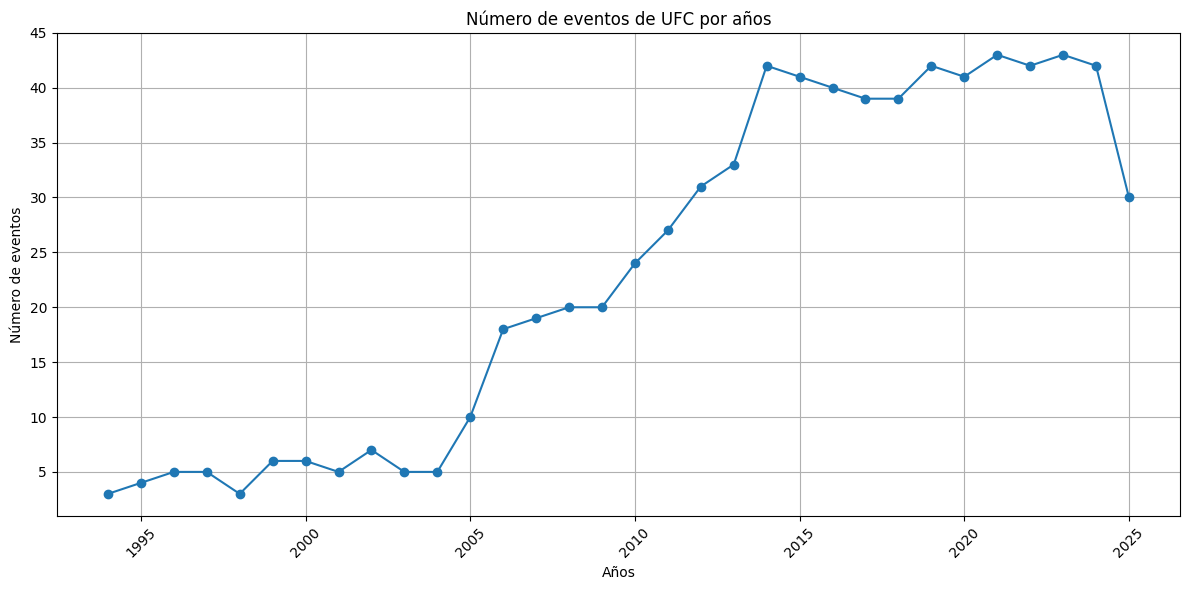

In [42]:
fechas = df_eventos["date"].unique()
años = []
#Bucle for para sacar los años de los eventos
for date_str in fechas:
    if isinstance(date_str, str):
        try:
            dt_object = datetime.strptime(date_str, "%B %d, %Y")
            años.append(dt_object.year)
        except ValueError:
            pass

# Calcular el número de eventos realizados por años
year_counts = pd.Series(años).value_counts().sort_index()

#Creación del grafico
plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title('Número de eventos de UFC por años')
plt.xlabel('Años')
plt.ylabel('Número de eventos')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ojo en 2025 salen menos porque los datos acaban en septiembre de 2025.

In [43]:
df_eventos.tail()

,event_id,fight_id,date,location,winner,winner_id
8332,a6a9ab5a824e8f66,3b020d4914b44fc8,"March 11, 1994","Denver, Colorado, USA",Orlando Wiet,a6c2f5381d575920
8333,a6a9ab5a824e8f66,d917c8c7461b9831,"March 11, 1994","Denver, Colorado, USA",Frank Hamaker,c3c23c99477c041b
8334,a6a9ab5a824e8f66,ccee020be2e8d9f6,"March 11, 1994","Denver, Colorado, USA",Johnny Rhodes,319fa1bd3176bded
8335,a6a9ab5a824e8f66,4b9ae533ccb3fcdf,"March 11, 1994","Denver, Colorado, USA",Patrick Smith,46c8ec317aff28ac
8336,a6a9ab5a824e8f66,4acab67848e78327,"March 11, 1994","Denver, Colorado, USA",Scott Morris,be9d259be012e8a4


### Contar y Visualizar Eventos de UFC por Ciudad

Contar el número de eventos únicos que se han realizado en cada ciudad utilizando el DataFrame `df_eventos`. Luego, crear un gráfico de barras para visualizar la cantidad de eventos por cada una de las 10 ciudades principales con más eventos, incluyendo etiquetas claras para los ejes y un título descriptivo. Finalmente, resumir las ciudades con más eventos de UFC y proporcionar cualquier otra observación relevante a partir del gráfico.

In [44]:
eventos_por_ciudad = df_eventos.groupby('location')['event_id'].nunique()

print("Número de eventos únicos por ciudad:")
display(eventos_por_ciudad.sort_values(ascending=False).head(10))

Número de eventos únicos por ciudad:


,event_id
location,
"Las Vegas, Nevada, USA",258
"Abu Dhabi, Abu Dhabi, United Arab Emirates",19
"London, England, United Kingdom",16
"Newark, New Jersey, USA",11
"Atlantic City, New Jersey, USA",10
"Anaheim, California, USA",10
"Houston, Texas, USA",9
"New York City, New York, USA",8
"Montreal, Quebec, Canada",8


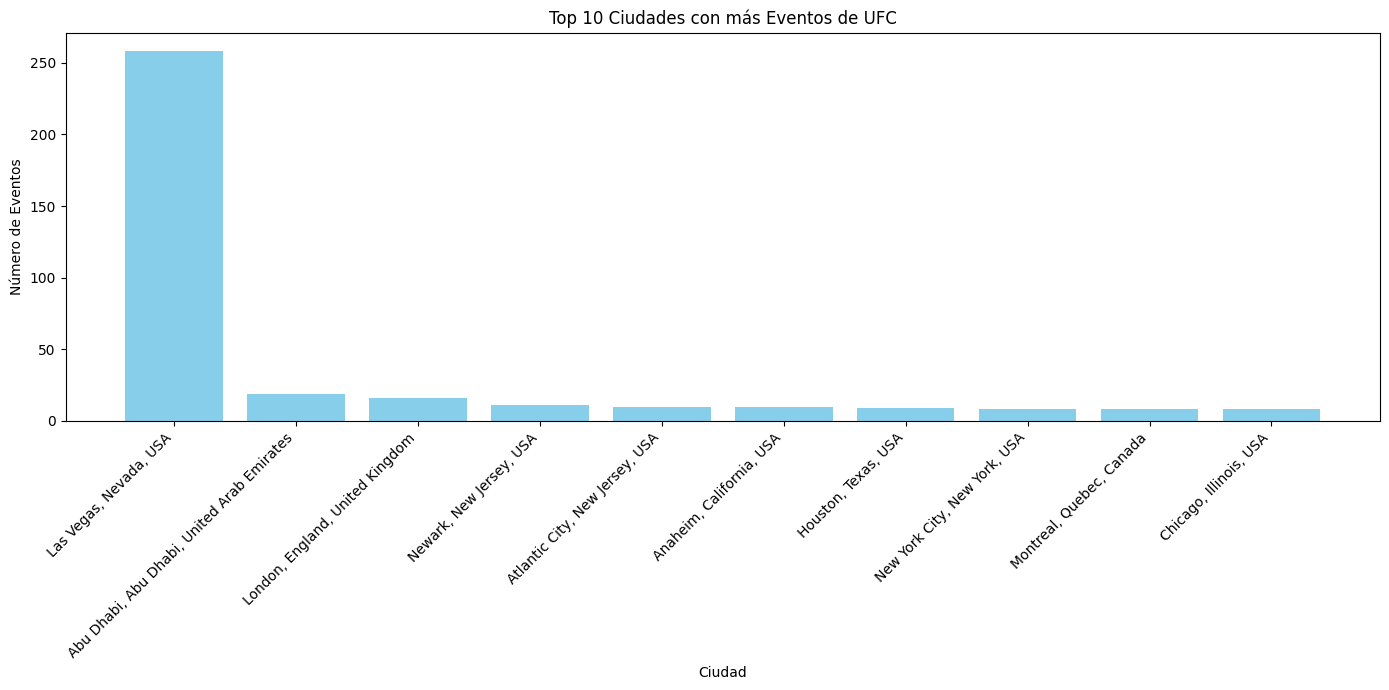

In [45]:
# Seleccionar las 10 ciudades con más eventos
top_10_ciudades = eventos_por_ciudad.sort_values(ascending=False).head(10)

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))
plt.bar(top_10_ciudades.index, top_10_ciudades.values, color='skyblue')
plt.xlabel('Ciudad')
plt.ylabel('Número de Eventos')
plt.title('Top 10 Ciudades con más Eventos de UFC')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()


### Resumen de Ciudades con más Eventos de UFC

El gráfico de barras muestra claramente que **Las Vegas, Nevada, USA**, es, con mucha diferencia, la ciudad con más eventos de UFC, albergando 258 eventos únicos. Esta cifra es considerablemente superior a la de la segunda ciudad en la lista.

Después de Las Vegas, las ciudades con más eventos son:

*   **Abu Dhabi, Abu Dhabi, United Arab Emirates**: 19 eventos
*   **London, England, United Kingdom**: 16 eventos
*   **Newark, New Jersey, USA**: 11 eventos
*   **Atlantic City, New Jersey, USA**: 10 eventos
*   **Anaheim, California, USA**: 10 eventos
*   **Houston, Texas, USA**: 9 eventos
*   **New York City, New York, USA**: 8 eventos
*   **Montreal, Quebec, Canada**: 8 eventos
*   **Chicago, Illinois, USA**: 8 eventos

**Observaciones Adicionales:**

*   La predominancia de Las Vegas es abrumadora, lo que sugiere su papel como epicentro de los eventos de la UFC, probablemente debido a la presencia de la sede principal de la organización y sus grandes instalaciones para espectáculos.
*   Varias ciudades estadounidenses aparecen en el top 10, lo que indica que Estados Unidos es un mercado clave para la UFC.
*   Hay una presencia internacional notable, con Abu Dhabi, Londres y Montreal destacándose como ubicaciones importantes fuera de EE. UU.

### Eventos en la pandemia (2020-2022)

In [46]:
df_eventos_pandemic = df_eventos.copy()

# Asegurarse de que la columna 'date' sea de tipo datetime
df_eventos_pandemic['date_dt'] = pd.to_datetime(df_eventos_pandemic['date'], format='%B %d, %Y', errors='coerce')

# Filtrar por el rango de fechas de la pandemia (2020-2022)
pandemic_events = df_eventos_pandemic[(df_eventos_pandemic['date_dt'].dt.year >= 2020) & (df_eventos_pandemic['date_dt'].dt.year <= 2022)]

# Contar el número de eventos únicos por año durante la pandemia
events_by_year_pandemic = pandemic_events.groupby(pandemic_events['date_dt'].dt.year)['event_id'].nunique().reset_index()
events_by_year_pandemic.columns = ['Año', 'Numero_de_Eventos']

print("Número de eventos de UFC por año durante la pandemia (2020-2022):")
display(events_by_year_pandemic)

# Filter for events in Las Vegas
las_vegas_pandemic_events = pandemic_events[pandemic_events['location'].str.contains('Las Vegas', case=False, na=False)]

# Count unique events per year for Las Vegas
events_by_year_las_vegas = las_vegas_pandemic_events.groupby(las_vegas_pandemic_events['date_dt'].dt.year)['event_id'].nunique().reset_index()
events_by_year_las_vegas.columns = ['Año', 'Numero_de_Eventos']

print("\nNúmero de eventos de UFC en Las Vegas por año durante la pandemia (2020-2022):")
display(events_by_year_las_vegas)

Número de eventos de UFC por año durante la pandemia (2020-2022):


,Año,Numero_de_Eventos
0,2020,41
1,2021,43
2,2022,42



Número de eventos de UFC en Las Vegas por año durante la pandemia (2020-2022):


,Año,Numero_de_Eventos
0,2020,23
1,2021,34
2,2022,25


## Analizar la Distribución Geográfica de Eventos de UFC

In [47]:
df_eventos_copy = df_eventos.copy()
# Extraer el nombre del país de la columna 'location'
df_eventos_copy['country_extracted'] = df_eventos_copy['location'].apply(lambda x: x.split(',')[-1].strip() if pd.notnull(x) else 'Unknown')

# Contar el número de eventos únicos por cada país
eventos_por_pais = df_eventos_copy.groupby('country_extracted')['event_id'].nunique()

print("Número de eventos únicos por país:")
display(eventos_por_pais.sort_values(ascending=False).head(10))

Número de eventos únicos por país:


,event_id
country_extracted,
USA,527
Brazil,40
Canada,35
United Kingdom,30
United Arab Emirates,21
Australia,19
Japan,9
China,8
Mexico,8


### Gráfico de Tarta por País

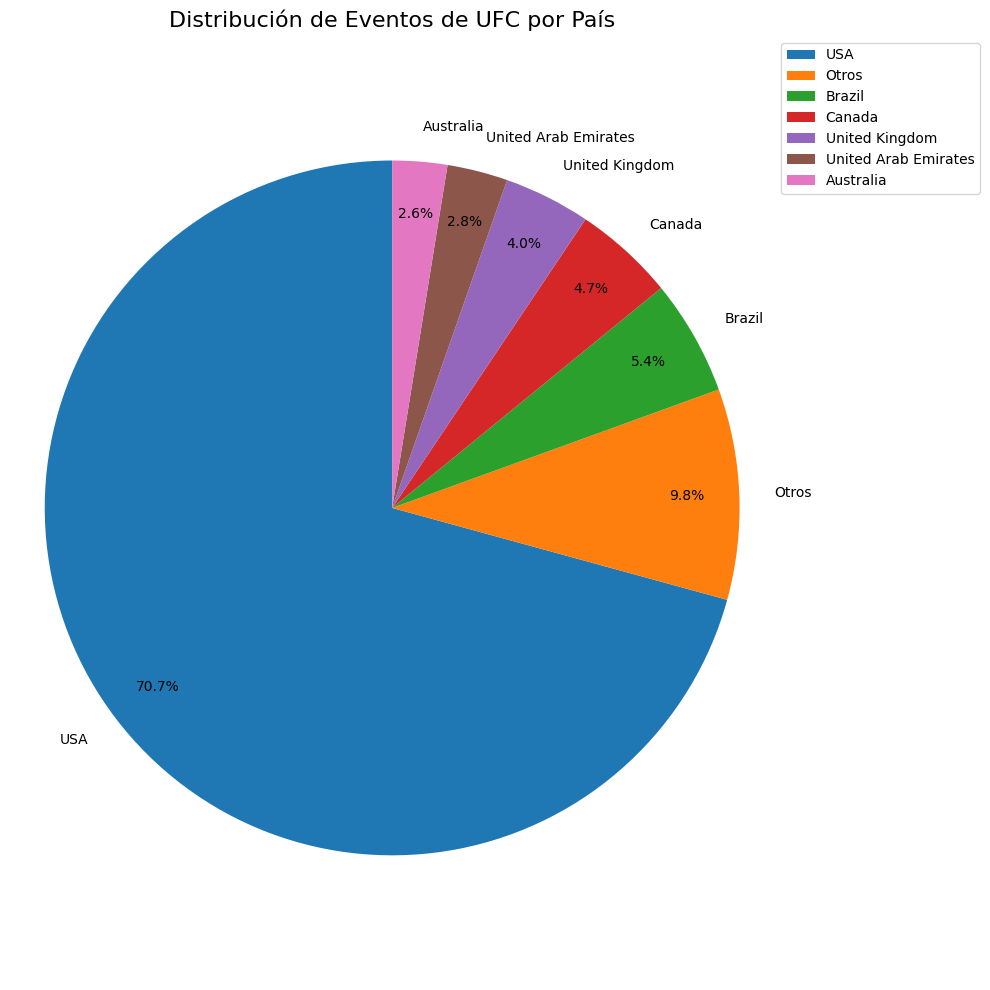

In [48]:
total_eventos = eventos_por_pais.sum()
threshold = total_eventos * 0.02 # Group countries with less than 2% of total events

# Identificar países a agrupar en 'Otros'
paises_otros = eventos_por_pais[eventos_por_pais < threshold]

# Crear una nueva serie para el gráfico
eventos_para_grafico = eventos_por_pais[eventos_por_pais >= threshold]

# Sumar los eventos de los países agrupados en 'Otros'
if not paises_otros.empty:
    eventos_para_grafico['Otros'] = paises_otros.sum()

# Ordenar para una mejor visualización si se desea (opcional)
eventos_para_grafico = eventos_para_grafico.sort_values(ascending=False)

# Crear el gráfico de tarta
plt.figure(figsize=(10, 10))
plt.pie(eventos_para_grafico, labels=eventos_para_grafico.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Distribución de Eventos de UFC por País', fontsize=16)
plt.axis('equal') # Asegura que el círculo sea proporcional
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Eventos por Ubicación (USA/No USA)



In [49]:
df_eventos_copy['location_category'] = df_eventos_copy['country_extracted'].apply(lambda x: 'Dentro de USA' if x == 'USA' else 'Fuera de USA')

events_by_usa_category = df_eventos_copy['location_category'].value_counts()

print("Número de eventos por categoría de ubicación (Inside USA / Outside USA):")
display(events_by_usa_category)

Número de eventos por categoría de ubicación (Inside USA / Outside USA):


,count
location_category,
Dentro de USA,5814
Fuera de USA,2523


## Gráfico de Barras (USA vs. No USA)

/tmp/ipykernel_1577/2760840991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=events_by_usa_category.index, y=events_by_usa_category.values, palette='viridis')


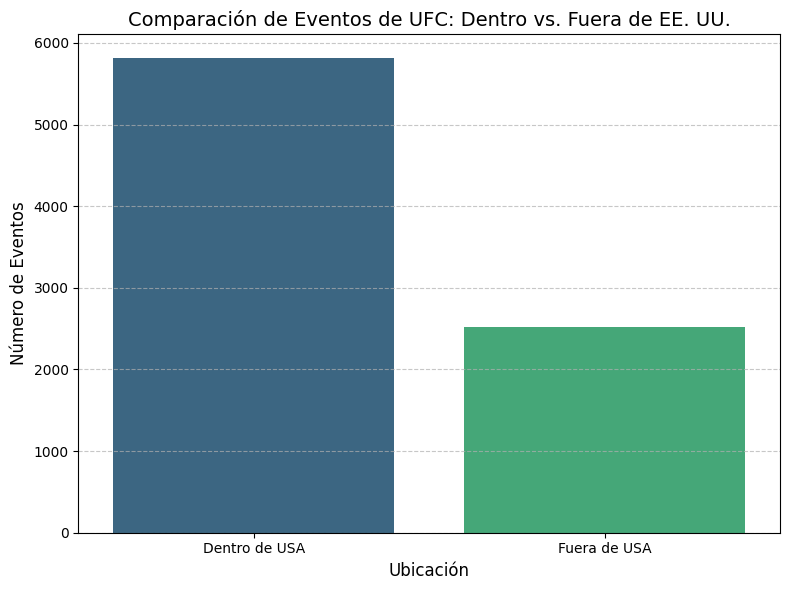

In [50]:
# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=events_by_usa_category.index, y=events_by_usa_category.values, palette='viridis')

# Añadir título y etiquetas
plt.title('Comparación de Eventos de UFC: Dentro vs. Fuera de EE. UU.', fontsize=14)
plt.xlabel('Ubicación', fontsize=12)
plt.ylabel('Número de Eventos', fontsize=12)

# Mostrar el gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Peleadores
### Histograma: de altura los peleadores

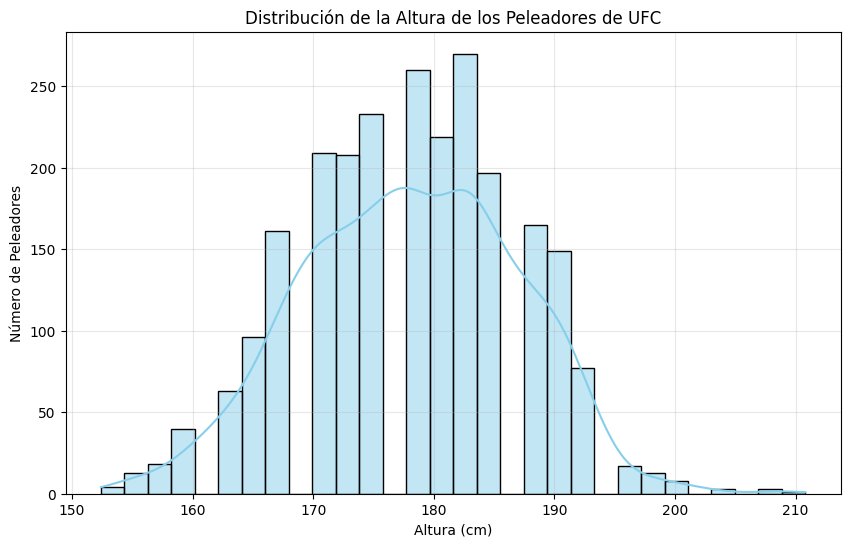

In [51]:
# Histograma para la Altura de los peleadores
plt.figure(figsize=(10, 6))
sns.histplot(df_peleadores_limpio['height'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de la Altura de los Peleadores de UFC')
plt.xlabel('Altura (cm)')
plt.ylabel('Número de Peleadores')
plt.grid(True, alpha=0.3)
plt.show()

### Histograma: Peso de peleadores

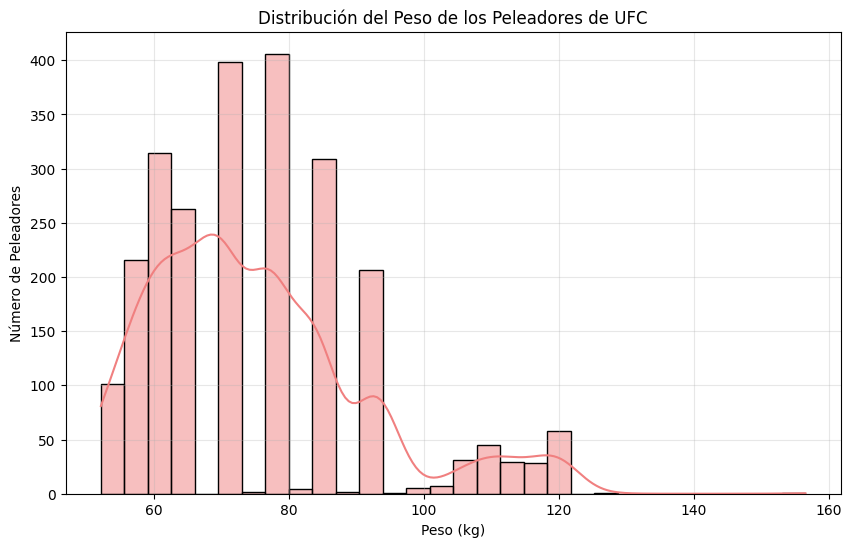

In [52]:
# Histograma para el Peso de los peleadores
plt.figure(figsize=(10, 6))
sns.histplot(df_peleadores_limpio['weight'], kde=True, bins=30, color='lightcoral')
plt.title('Distribución del Peso de los Peleadores de UFC')
plt.xlabel('Peso (kg)')
plt.ylabel('Número de Peleadores')
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
# Identificar IDs de peleadoras de las divisiones femeninas en df_general_pre_fight
women_divisions = [col for col in df_general_pre_fight['division'].unique() if "women's" in str(col).lower()]

female_fighter_ids = pd.concat([
    df_general_pre_fight[df_general_pre_fight['division'].isin(women_divisions)]['r_id'],
    df_general_pre_fight[df_general_pre_fight['division'].isin(women_divisions)]['b_id']
]).unique()

# Crear una columna 'sex' en df_peleadores_limpio
df_peleadores_limpio['sex'] = df_peleadores_limpio['id'].apply(lambda x: 'Female' if x in female_fighter_ids else 'Male')

print("Distribución de peleadores por sexo:")
display(df_peleadores_limpio['sex'].value_counts())

Distribución de peleadores por sexo:


,count
sex,
Male,2174
Female,253


### Histograma: Altura de peleadores masculinos

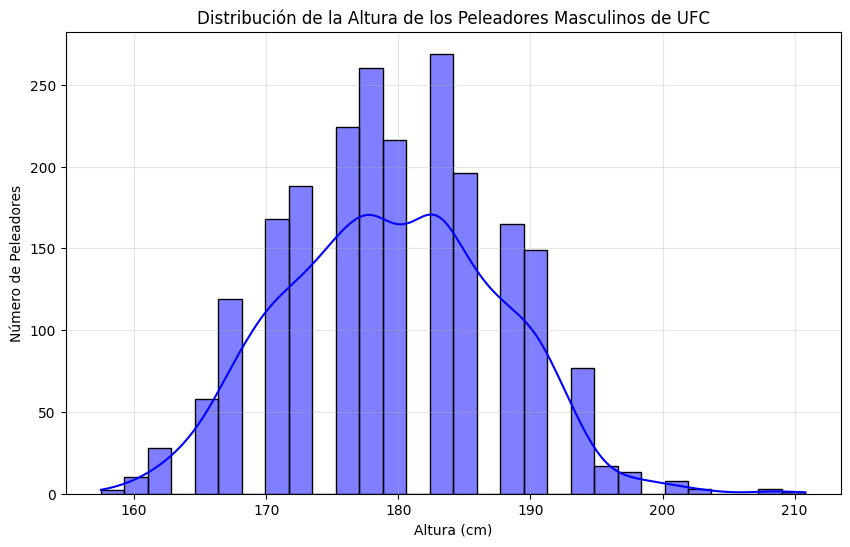

In [54]:
# Filtrar datos por sexo
df_male = df_peleadores_limpio[df_peleadores_limpio['sex'] == 'Male']
df_female = df_peleadores_limpio[df_peleadores_limpio['sex'] == 'Female']

# Histograma de Altura para Hombres
plt.figure(figsize=(10, 6))
sns.histplot(data=df_male, x='height', kde=True, bins=30, color='blue')
plt.title('Distribución de la Altura de los Peleadores Masculinos de UFC')
plt.xlabel('Altura (cm)')
plt.ylabel('Número de Peleadores')
plt.grid(True, alpha=0.3)
plt.show()

Podemos ver que la estatura media está entre los 1.70m y 1.90m si tenemos bins vacios es porque los datos realmente se recogen en pies (unidad) y luego se pasan a cm y las medidas imperiales son menos precisas que las metricas.

### Histograma: Altura de peleadoras

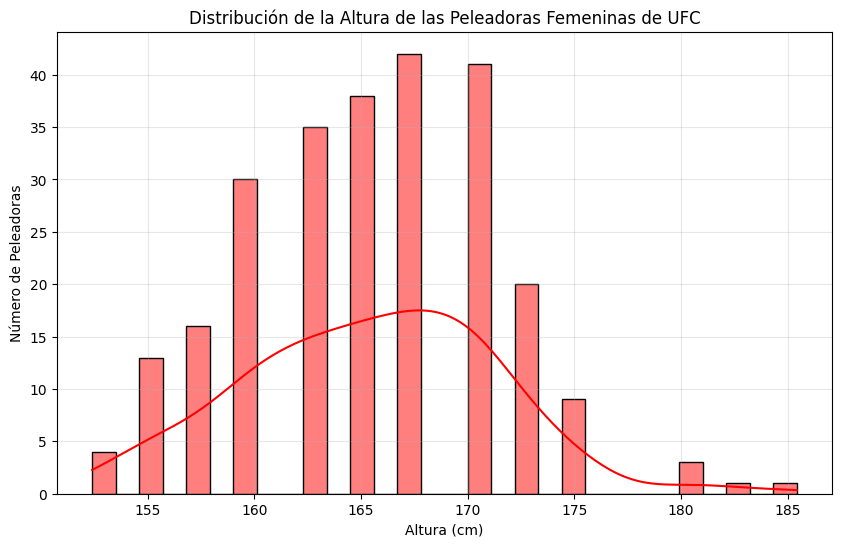

In [55]:
# Histograma de Altura para Mujeres
plt.figure(figsize=(10, 6))
sns.histplot(data=df_female, x='height', kde=True, bins=30, color='red')
plt.title('Distribución de la Altura de las Peleadoras Femeninas de UFC')
plt.xlabel('Altura (cm)')
plt.ylabel('Número de Peleadoras')
plt.grid(True, alpha=0.3)
plt.show()

vemos que las estaturas promedio van de 160 al 172cm.

### Histograma: Peso de peleadores masculinos

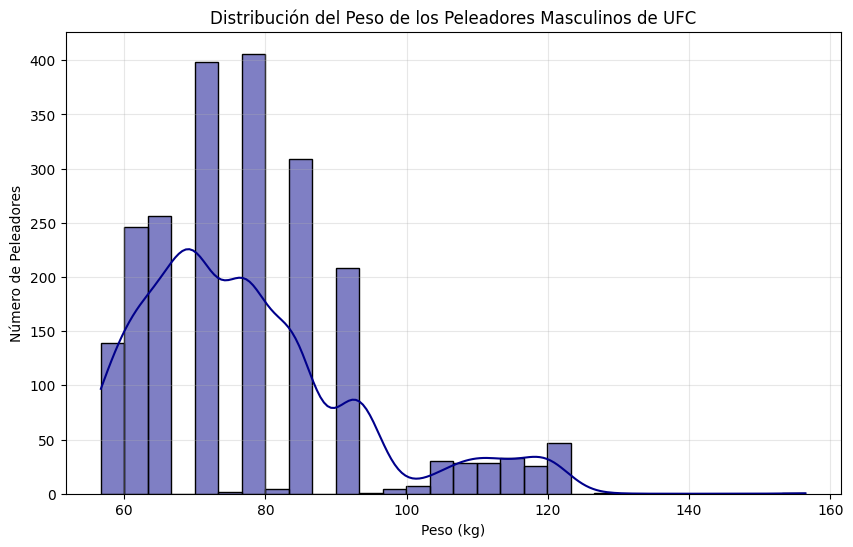

In [56]:
# Histograma de Peso para Hombres
plt.figure(figsize=(10, 6))
sns.histplot(data=df_male, x='weight', kde=True, bins=30, color='darkblue')
plt.title('Distribución del Peso de los Peleadores Masculinos de UFC')
plt.xlabel('Peso (kg)')
plt.ylabel('Número de Peleadores')
plt.grid(True, alpha=0.3)
plt.show()

el peso esta por categoría:


*   Peso pesado: superior a 205 libras (93 kg) e inferior a 265 libras (120,2)
*   Peso semipesado: inferior a 205 libras (93 kg).
*   Peso medio: inferior a 185 libras (83,9 kg).
*   Peso welter: inferior a 170 libras (77,1 kg).
*   Peso ligero: inferior a 155 libras (70,3 kg).
*   Peso pluma: inferior a 145 libras (65,8 kg).
*   Peso gallo: inferior a 135 libras (61,2 kg).
*   Peso mosca: inferior a 125 libras (56,7 kg).

Podemos ver que hay una barra por peso hasta llegar a los +93 kg que son los pesos pesados donde podemos ver más disparidad

También gracías ello podemos observar que las categorías con más peleadores son la de peso ligero y el peso welter que son las de 70,3kg y 77,1kg.

### Histograma: Peso de peleadoras femeninas

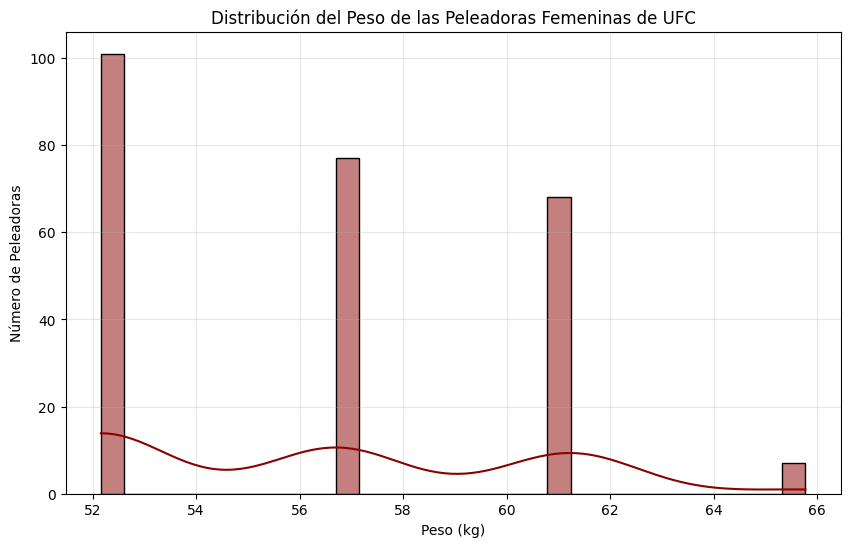

In [57]:
# Histograma de Peso para Mujeres
plt.figure(figsize=(10, 6))
sns.histplot(data=df_female, x='weight', kde=True, bins=30, color='darkred')
plt.title('Distribución del Peso de las Peleadoras Femeninas de UFC')
plt.xlabel('Peso (kg)')
plt.ylabel('Número de Peleadoras')
plt.grid(True, alpha=0.3)
plt.show()

Los pesos son las 4 categorías femininas que han existido recientemente han eliminado la división peso pluma 65.8kg


* Peso Gallo: 61.2kg
* Peso mosca: 56.7kg
* Peso paja:  52.2kg

### Histograma: Alcance de peleadores

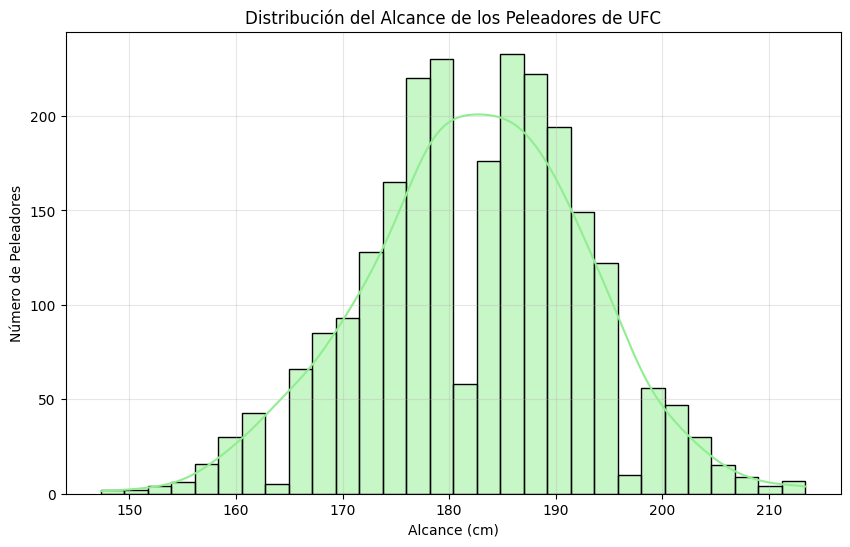

In [58]:
# Histograma para el Alcance de los peleadores
plt.figure(figsize=(10, 6))
sns.histplot(df_peleadores_limpio['reach'], kde=True, bins=30, color='lightgreen')
plt.title('Distribución del Alcance de los Peleadores de UFC')
plt.xlabel('Alcance (cm)')
plt.ylabel('Número de Peleadores')
plt.grid(True, alpha=0.3)
plt.show()

vemos como el alcance esta entorno a 170cm a 190cm.

### Distribución de tipo de guardia

In [59]:
# Obtener el conteo de cada tipo de guardia (stance)
stance_counts = df_peleadores_limpio['stance'].value_counts()

# Agrupar las guardias menos comunes en 'Other' para una mejor visualización si hay muchas categorías
# Definimos un umbral, por ejemplo, si una categoría representa menos del 2% del total, se agrupa.
threshold = 0.02 * stance_counts.sum()

main_stances = stance_counts[stance_counts >= threshold]
other_stances_count = stance_counts[stance_counts < threshold].sum()

# Si hay "otras" guardias, las añadimos a la serie para el gráfico
if other_stances_count > 0:
    main_stances['Other'] = other_stances_count

# Crear el gráfico de tarta con Plotly
fig = px.pie(main_stances,
             values=main_stances.values,
             names=main_stances.index,
             title='Distribución de Tipos de Guardia (Stance) entre los Peleadores de UFC',
             hole=0.3, # Crea un donut chart
             color_discrete_sequence=px.colors.sequential.RdBu)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=True, font=dict(size=14))

fig.show()


Podemos ver que 76.5% de los peleadores tienen la guardia derecha  luego los 17.2% guarida izquierda y switch como guardia cambiante es decir que durante la pelea utiliza las 2 guardias usando la más conveniento en cada momento del combate.

### Distribución Altura-Peso

In [60]:
px.scatter(df_peleadores_limpio, x='height', y='weight',color='sex')

In [61]:
df_peleadores_limpio[df_peleadores_limpio['weight']==156.49]

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,dob,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg,dob_datetime,dob_ordinal,strike_efficiency_ratio,win_ratio,total_fights,weighted_strike_efficiency_ratio,sex
61,f348d05403fad037,Dan Bobish,NaN,17,9,0,187.96,156.49,192.623064,Southpaw,1970/01/26,2.06,44,1.74,34,2.44,42,0,1.6,1970-01-26,719188,1.183908,0.653846,2,1.183908,Male


el outlier viene de la antigua ufc donde no habia categorias de peso.

### Tipos de finalización según la división

<Figure size 1500x1000 with 0 Axes>

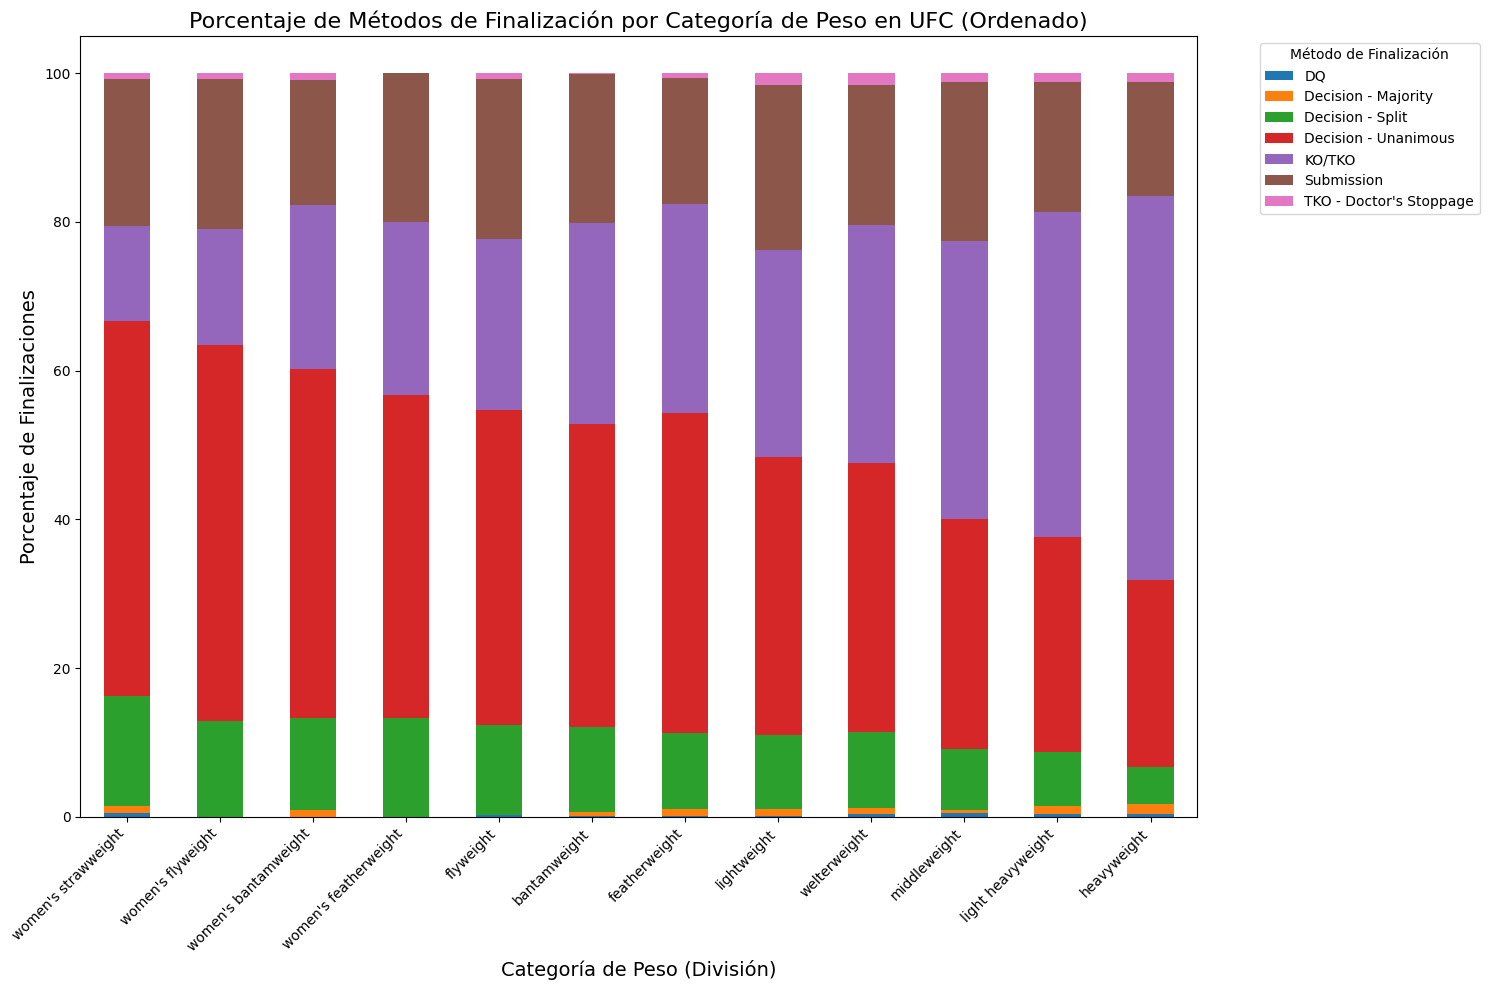

In [62]:
# Agrupar por 'division' y 'method' y contar las ocurrencias
finish_counts = df_general_pre_fight.groupby(['division', 'method']).size().reset_index(name='count')

# Pivotear la tabla para un gráfico de barras apiladas más fácil
pivoted_counts = finish_counts.pivot(index='division', columns='method', values='count').fillna(0)

# Ordenar las divisiones por el número total de peleas para una mejor visualización
pivoted_counts['total_fights'] = pivoted_counts.sum(axis=1)
pivoted_counts = pivoted_counts.sort_values(by='total_fights', ascending=False).drop(columns='total_fights')

# Calculamos el porcentaje de cada método de finalización por división
# Dividimos cada valor por la suma de la fila (total de finalizaciones en esa división)
percentage_by_division_method = pivoted_counts.apply(lambda x: x / x.sum(), axis=1) * 100

# Definir el orden deseado para las divisiones
division_order = [
    "women's strawweight",
    "women's flyweight",
    "women's bantamweight",
    "women's featherweight",
    "flyweight",
    "bantamweight",
    "featherweight",
    "lightweight",
    "welterweight",
    "middleweight",
    "light heavyweight",
    "heavyweight"
]

# Reindexar el DataFrame de porcentajes para que siga el orden definido
# Solo incluimos las divisiones que existen en nuestro dataframe
existing_divisions = [div for div in division_order if div in percentage_by_division_method.index]
percentage_by_division_method_ordered = percentage_by_division_method.reindex(existing_divisions)

# Crear el gráfico de barras apiladas con los porcentajes ordenados
plt.figure(figsize=(15, 10))
percentage_by_division_method_ordered.plot(kind='bar', stacked=True, figsize=(15, 10))

plt.title('Porcentaje de Métodos de Finalización por Categoría de Peso en UFC (Ordenado)', fontsize=16)
plt.xlabel('Categoría de Peso (División)', fontsize=14)
plt.ylabel('Porcentaje de Finalizaciones', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de Finalización', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Podemos ver que la mayoría de peleas terminan por decisión sobretodo por decisión unanime en la mayoría de divisiones, también podemos ver como va aumentando el peso hay más KO/TKO hasta llegar al peso pesado donde lo normal es que termine en KO/TKO.

### Relación entre Golpes Significativos Absorbidos (SAPM) y Lanzados (SPLM)

In [63]:
fig = px.scatter(df_peleadores_limpio,
                 x='sapm',
                 y='splm',
                 title='Relación entre Golpes Significativos Absorbidos (SAPM) y Lanzados (SPLM)',
                 labels={'sapm': 'Golpes Absorbidos por Minuto (SAPM)', 'splm': 'Golpes Lanzados por Minuto (SPLM)'},
                 hover_name='name',
                 opacity=0.6,
                 trendline='ols',
                 trendline_color_override='red')

fig.update_layout(xaxis_title='SAPM', yaxis_title='SPLM')
fig.show()

Podemos ver que los peleadores que reciben más golpes también lanzan más es decir que no tienen miedo a intercambiar golpes.

## Agrupación de Peleadores por Tipo de Habilidad (K-Means Clustering)

Utilizaremos las siguientes características para clasificar a los peleadores:
*   **Striker:** `splm`, `sapm`, `str_acc`, `str_def`
*   **Wrestler:** `td_avg`, `td_avg_acc`, `td_def` ,`sub_avg`

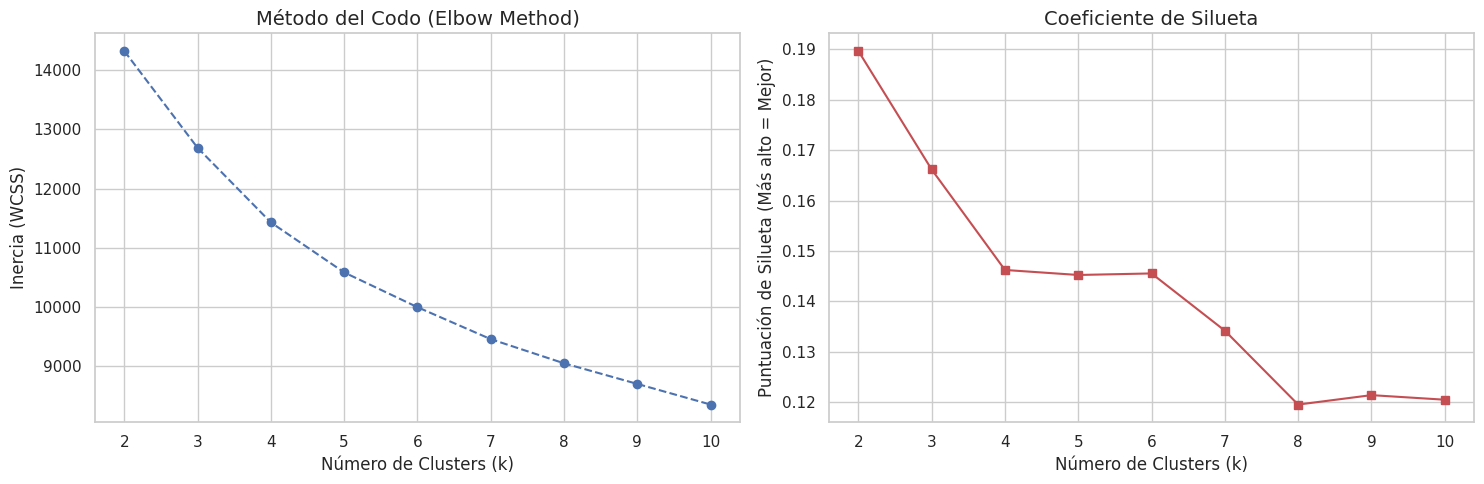

In [64]:
# 1. Preparación idéntica a tu página web
columnas_estilo = ['splm', 'sapm', 'str_acc', 'str_def', 'td_avg', 'td_def', 'sub_avg']
df_pca_clean = df_peleadores_limpio.dropna(subset=columnas_estilo).copy() # Changed df to df_peleadores_limpio
X_estilo = df_pca_clean[columnas_estilo]
X_scaled = StandardScaler().fit_transform(X_estilo)

# Listas para guardar los resultados de cada prueba
inercias = []
siluetas = []
rango_k = range(2, 11) # Vamos a probar desde 2 hasta 10 grupos

# 2. Bucle de prueba
for k in rango_k:
    # Entrenamos un modelo para este número de grupos específico
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)

    # Guardamos la Inercia (qué tan apretados están los puntos dentro de su grupo)
    inercias.append(kmeans.inertia_)

    # Guardamos la Silueta (qué tan bien separados están los grupos entre sí)
    score_silueta = silhouette_score(X_scaled, etiquetas)
    siluetas.append(score_silueta)

# 3. Dibujamos los resultados
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Método del Codo
ax1.plot(rango_k, inercias, marker='o', linestyle='--', color='b')
ax1.set_title('Método del Codo (Elbow Method)', fontsize=14)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')

# Gráfico 2: Análisis de Silueta
ax2.plot(rango_k, siluetas, marker='s', linestyle='-', color='r')
ax2.set_title('Coeficiente de Silueta', fontsize=14)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Puntuación de Silueta (Más alto = Mejor)')

plt.tight_layout()
plt.show()

Peleadores agrupados en 2 tipos:



,count
fighter_type,
1,1265
0,1162



Características promedio de cada tipo de peleador (en la escala original):


,splm,str_acc,td_avg,td_avg_acc,sub_avg,fighter_type
0,2.95,46.07,2.47,51.35,0.90,0
1,3.42,42.07,0.58,18.91,0.34,1


/tmp/ipykernel_1577/3891101919.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




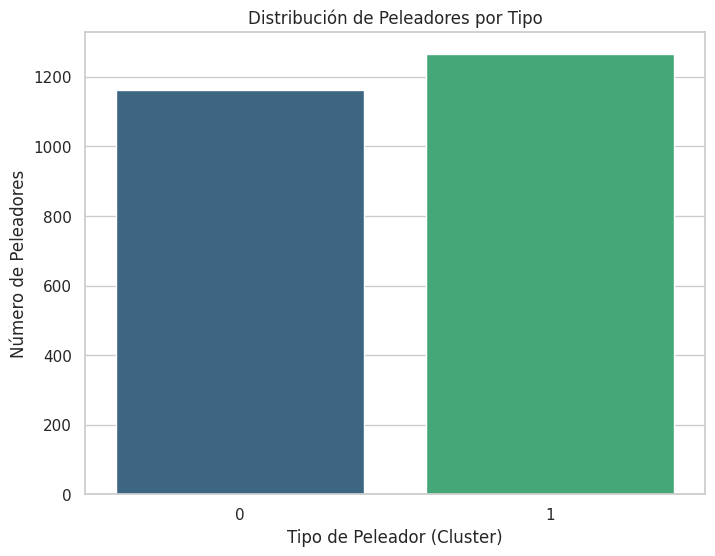

In [65]:

# 1. Seleccionar características relevantes
features = [
    'splm', 'str_acc',
    'td_avg', 'td_avg_acc',
    'sub_avg'
]

df_clustering = df_peleadores_limpio[features].copy()

# Manejar valores nulos si los hubiera (imputar con la mediana para mayor robustez)
# Aunque ya se hizo una limpieza previa, es buena práctica verificar.
for col in features:
    if df_clustering[col].isnull().any():
        df_clustering[col] = df_clustering[col].fillna(df_clustering[col].median())


# 2. Escalar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# 3. Aplicar K-Means
k = 2 # Número de clusters (tipos de peleadores)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar warnings
df_peleadores_limpio['fighter_type'] = kmeans.fit_predict(df_scaled)

print(f"Peleadores agrupados en {k} tipos:\n")
display(df_peleadores_limpio['fighter_type'].value_counts())

# 4. Caracterizar los clusters
# Desescalar los centroides para interpretarlos en la escala original
centroids_scaled = kmeans.cluster_centers_
centroids_original_scale = scaler.inverse_transform(centroids_scaled)

df_centroids = pd.DataFrame(centroids_original_scale, columns=features)
df_centroids['fighter_type'] = range(k)

print("\nCaracterísticas promedio de cada tipo de peleador (en la escala original):")
display(df_centroids.round(2))

# Visualización de la distribución de los tipos
plt.figure(figsize=(8, 6))
sns.countplot(x='fighter_type', data=df_peleadores_limpio, palette='viridis')
plt.title('Distribución de Peleadores por Tipo')
plt.xlabel('Tipo de Peleador (Cluster)')
plt.ylabel('Número de Peleadores')
plt.show()

In [66]:
# Suponiendo que viste que el grupo 0 pega más y el grupo 1 derriba más:
df_peleadores_limpio['estilo'] = df_peleadores_limpio['fighter_type'].map({0: 'Striker', 1: 'Wrestler'})

In [67]:
# Ver 5 ejemplos del Grupo 0 (Reemplaza los nombres si los cambiaste)
print("🥋 EJEMPLOS DEL GRUPO 0:")
display(df_peleadores_limpio[df_peleadores_limpio['fighter_type'] == 0][['name', 'splm', 'td_avg']].head(5))

# Ver 5 ejemplos del Grupo 1
print("\n🥊 EJEMPLOS DEL GRUPO 1:")
display(df_peleadores_limpio[df_peleadores_limpio['fighter_type'] == 1][['name', 'splm', 'td_avg']].head(5))

# Buscar a un peleador en concreto para ver qué opina la IA de él:
peleador_test = "Khabib Nurmagomedov"
print(f"\n🔍 Estilo detectado para {peleador_test}:")
display(df_peleadores_limpio[df_peleadores_limpio['name'] == peleador_test][['name', 'fighter_type']])
display(df_peleadores_limpio[df_peleadores_limpio['name'] == 'Ciryl Gane'][['name', 'fighter_type']])

🥋 EJEMPLOS DEL GRUPO 0:


,name,splm,td_avg
1,Deron Winn,4.55,4.28
2,Gegard Mousasi,3.75,1.59
3,Mike Pierce,2.62,3.08
4,Hyun Gyu Lim,4.45,0.23
5,Bo Nickal,2.36,3.34



🥊 EJEMPLOS DEL GRUPO 1:


,name,splm,td_avg
0,Jessica Aguilar,4.93,0.94
6,Phil Harris,2.34,1.76
8,Tom Gallicchio,3.53,1.00
12,Matt Dwyer,2.57,0.44
15,Hannah Goldy,5.19,0.66



🔍 Estilo detectado para Khabib Nurmagomedov:


,name,fighter_type
2551,Khabib Nurmagomedov,0


,name,fighter_type
436,Ciryl Gane,1


In [68]:
# 1. Aplicar PCA a los datos escalados
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)

# 2. Asignar ejes geométricos neutros
df_peleadores_limpio['PC1'] = pca_components[:, 0]
df_peleadores_limpio['PC2'] = pca_components[:, 1]

# 3. Crear el gráfico de dispersión con Plotly Express
fig = px.scatter(df_peleadores_limpio,
                 x='PC1',
                 y='PC2',
                 color='fighter_type',
                 hover_name='name',
                 title='Visualización de Clústeres de Peleadores (PCA + K-Means)',
                 labels={'PC1': 'Componente Principal 1 (Varianza Max)', 'PC2': 'Componente Principal 2 (Varianza Ortogonal)'},
                 opacity=0.8)

fig.update_layout(showlegend=True)
fig.show()

### Análisis Detallado de las Características Promedio por Tipo de Peleador (2 Clusters)

A continuación, mostramos la tabla `df_centroids` con los valores promedio de las características de cada uno de los 2 clusters:

In [69]:
display(df_centroids.round(2))

,splm,str_acc,td_avg,td_avg_acc,sub_avg,fighter_type
0,2.95,46.07,2.47,51.35,0.90,0
1,3.42,42.07,0.58,18.91,0.34,1


#### Interpretación de los 2 Tipos de Peleadores:

*   **Cluster 0 - Los "Wrestlers":**
    *   `splm` (Golpes Lanzados por Minuto): Bajo (2.95).
    *   `str_acc` (Precisión de Golpeo): Moderada (46.07%).
    *   `td_avg` (Derribos Promedio): **Alto (2.47)**. Muestran una clara tendencia a buscar el derribo.
    *   `td_avg_acc` (Precisión de Derribos): **Alto (51.35%)**. Son eficientes en sus intentos.
    *   `sub_avg` (Intentos de Sumisión Promedio): **Alto (0.9)**. Tienen una presencia significativa de sumisiones.
    *   **Conclusión:** Este tipo de peleador se caracteriza por su fuerte enfoque en el grappling, buscando activamente los derribos y sumisiones. Son competentes en la defensa de golpeo, pero su juego principal es el control en el suelo y la finalización por sumisión. Podrían considerarse los **"Grapplers / Wrestlers con Amenaza de Sumisión"**.

*   **Cluster 1 - Los "Strikers" de Volumen y con Menor Énfasis en Lucha:**
    *   `splm`: **Alto (3.42)**. Lanzan un volumen considerable de golpes.
    *   `str_acc`: Ligeramente más baja (42.07%) que el Cluster 0.
    *   `td_avg` (Derribos Promedio): **Bajo (0.56)**. No buscan el derribo activamente.
    *   `td_avg_acc` (Precisión de Derribos): **Muy Baja (18.91%)**.
    *   `sub_avg` (Intentos de Sumisión Promedio): Muy Bajo (0.34).
    *   **Conclusión:** Este grupo se enfoca principalmente en el intercambio de golpes de pie. Lanzan muchos golpes pero también son más propensos a recibirlos, y tienen una presencia mínima en el aspecto de lucha y sumisiones. Podrían ser los **"Strikers Puros / Brawlers"**.

In [70]:
    # 1. Ver cuánta información retienen estos dos ejes
varianza = pca.explained_variance_ratio_
print(f"El PC1 explica el {varianza[0]*100:.1f}% de la varianza total.")
print(f"El PC2 explica el {varianza[1]*100:.1f}% de la varianza total.")

print(f"Total de información retenida: {(varianza[0] + varianza[1])*100:.1f}%\n")

# 2. Imprimir las Cargas (Loadings) para entender los ejes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1 (Estilo)', 'PC2 (Volumen/Ritmo)'], # Removed 'PC3 (Otro)'
    index=features
)

print("⚖️ PESOS DE LAS VARIABLES EN CADA COMPONENTE (LOADINGS):")
display(loadings.round(2))

El PC1 explica el 33.3% de la varianza total.
El PC2 explica el 27.6% de la varianza total.
Total de información retenida: 60.8%

⚖️ PESOS DE LAS VARIABLES EN CADA COMPONENTE (LOADINGS):


,PC1 (Estilo),PC2 (Volumen/Ritmo)
splm,0.03,0.73
str_acc,0.37,0.51
td_avg,0.64,-0.13
td_avg_acc,0.60,0.01
sub_avg,0.30,-0.44


### Relación alcence/altura con el ratio de victorias

In [71]:
# Calcular el ratio de alcance a altura y añadirlo como una nueva columna
df_peleadores_limpio['ratio_reach_height'] = df_peleadores_limpio['reach'] / df_peleadores_limpio['height']

# Mostrar las primeras filas con la nueva columna para verificación
print("DataFrame con la nueva columna 'ratio_reach_height':")
display(df_peleadores_limpio[['name', 'reach', 'height', 'ratio_reach_height']].head())

DataFrame con la nueva columna 'ratio_reach_height':


,name,reach,height,ratio_reach_height
0,Jessica Aguilar,160.02,160.02,1.000000
1,Deron Winn,177.80,167.64,1.060606
2,Gegard Mousasi,193.04,187.96,1.027027
3,Mike Pierce,180.34,172.72,1.044118
4,Hyun Gyu Lim,195.58,190.50,1.026667


In [72]:
fig = px.scatter(data_frame=df_peleadores_limpio,
                 x='win_ratio',
                 y='ratio_reach_height',
                 color='sex', # Mantenemos el color por sexo si ya lo tenías o lo añadimos
                 hover_name='name',
                 title='Relación entre Ratio de Victorias y Ratio Alcance/Altura por Peleador',
                 labels={'win_ratio': 'Ratio de Victorias', 'ratio_reach_height': 'Ratio Alcance/Altura'},
                 trendline='ols', # Añade la línea de regresión lineal (OLS)
                 trendline_color_override='black') # Color para la línea de tendencia

fig.update_layout(showlegend=True)
fig.show()

hay una pequeña correlacción entre mayor ratio alcance/altura mayor winrate pero no es una correlación significativa.

# Feature engeneering

### EDAD

In [73]:
# Trabajamos sobre el dataframe principal
df = df_general_pre_fight.copy()

print("⏳ Calculando edades exactas para cada pelea...")

# 1. ASEGURAR FORMATO DATETIME
# Convertimos la fecha de la pelea y la de nacimiento a objetos de tiempo
df['date'] = pd.to_datetime(df['date'])

# Hacemos lo mismo con los DOB (si hay errores, los convierte en NaT - Not a Time)
df['r_dob'] = pd.to_datetime(df['r_dob'], errors='coerce')
df['b_dob'] = pd.to_datetime(df['b_dob'], errors='coerce')

# 2. CÁLCULO MATEMÁTICO DE LA EDAD
# Fórmula: (Fecha Pelea - Fecha Nacimiento) / 365.25 días
# Usamos .dt.days para obtener el número de días
df['r_age'] = (df['date'] - df['r_dob']).dt.days / 365.25
df['b_age'] = (df['date'] - df['b_dob']).dt.days / 365.25

# 3. IMPUTAR EDADES FALTANTES CON LA MEDIA
# Si algún luchador no tenía DOB, su edad será NaN.
# Rellenamos esos huecos con la media de edad de TODOS los luchadores en el dataset
mean_age = pd.concat([df['r_age'], df['b_age']]).mean()

print(f"ℹ️ La edad promedio histórica en UFC es: {mean_age:.2f} años")

df['r_age'] = df['r_age'].fillna(mean_age)
df['b_age'] = df['b_age'].fillna(mean_age)

# 4. LIMPIEZA FINAL
# Ahora que tenemos la edad, las columnas 'dob' y 'date' (si no la usas para series temporales) sobran para el modelo predictivo clásico.
# Pero OJO: 'date' quizás la quieras guardar para ordenar, así que solo borramos los DOB.
cols_to_drop = ['r_dob', 'b_dob']
df = df.drop(columns=cols_to_drop)

print("✅ Columnas 'r_age' y 'b_age' creadas.")
print(f"🗑️ Columnas eliminadas: {cols_to_drop}")

# 5. VERIFICACIÓN
print("\n--- Ejemplo de Edades Calculadas ---")
display(df[['r_name', 'r_age', 'b_name', 'b_age', 'date']].sample(5))

# Guardamos en tu variable original
df_general_pre_fight = df

⏳ Calculando edades exactas para cada pelea...
ℹ️ La edad promedio histórica en UFC es: 30.38 años
✅ Columnas 'r_age' y 'b_age' creadas.
🗑️ Columnas eliminadas: ['r_dob', 'b_dob']

--- Ejemplo de Edades Calculadas ---


,r_name,r_age,b_name,b_age,date
2431,Jimmy Flick,30.283368,Cody Durden,29.727584,2020-12-19
4061,Joshua Burkman,37.300479,Drew Dober,28.774812,2017-07-29
7170,Jesse Lennox,27.414100,Danillo Villefort,26.253251,2009-08-08
1821,Damon Jackson,33.590691,Kamuela Kirk,27.912389,2022-03-12
5260,Jordan Mein,25.308693,Thiago Alves,31.329227,2015-01-31


##Ape index = indice de simios

In [74]:
df_general_pre_fight['r_ape_index'] = df_general_pre_fight['r_reach'] / df_general_pre_fight['r_height']
df_general_pre_fight['b_ape_index'] = df_general_pre_fight['b_reach'] / df_general_pre_fight['b_height']
df_general_pre_fight.head()

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id,r_age,b_age,r_ape_index,b_ape_index
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,3.0,Benoit Saint Denis,c2299ec916bc7c56,0.0,17.0,38.0,0.44,37.0,61.0,0.61,3.0,10.0,0.30,1.0,278.0,9.0,26.0,0.35,8.0,12.0,0.67,0.0,0.0,0.00,9.0,26.0,0.35,3.0,3.0,1.00,5.0,9.0,0.56,52.0,47.0,0.0,52.0,17.0,29.0,14,3,0,180.34,70.31,185.42,Southpaw,5.05,0.55,4.19,42,4.35,0.37,70,1.6,Mauricio Ruffy,9c393e836a852f30,0.0,5.0,17.0,0.29,6.0,18.0,0.33,0.0,0.0,0.0,0.0,34.0,4.0,14.0,0.28,1.0,3.0,0.33,0.0,0.0,0.00,5.0,17.0,0.28,0.0,0.0,0.00,0.0,0.0,0.00,80.0,20.0,0.0,100.0,0.0,0.0,12,1,0,180.34,70.31,190.50,Orthodox,3.84,0.57,4.16,60,0.00,0.00,84,0.0,Benoit Saint Denis,c2299ec916bc7c56,29.719370,29.221081,1.028169,1.056338
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,5.0,Nassourdine Imavov,881bf86d4cba8578,0.0,81.0,162.0,0.50,89.0,170.0,0.52,0.0,0.0,0.00,0.0,29.0,53.0,118.0,0.45,14.0,26.0,0.54,14.0,18.0,0.78,79.0,160.0,0.49,2.0,2.0,1.00,0.0,0.0,0.00,65.0,17.0,17.0,97.0,2.0,0.0,16,4,0,190.50,83.91,190.50,Orthodox,4.28,0.54,3.17,58,0.74,0.32,81,1.0,Caio Borralho,4126a78111c0855a,0.0,66.0,166.0,0.39,89.0,190.0,0.47,0.0,5.0,0.0,0.0,80.0,39.0,109.0,0.36,14.0,38.0,0.37,13.0,19.0,0.68,59.0,159.0,0.37,7.0,7.0,1.00,0.0,0.0,0.00,59.0,21.0,19.0,89.0,10.0,0.0,17,1,0,185.42,83.91,190.50,Southpaw,3.44,0.56,2.50,60,1.28,0.48,76,0.4,Nassourdine Imavov,881bf86d4cba8578,29.516769,32.637919,1.000000,1.027397
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,3.0,Modestas Bukauskas,476fe566d2df676e,0.0,22.0,36.0,0.61,29.0,44.0,0.66,0.0,0.0,0.00,0.0,110.0,18.0,30.0,0.60,0.0,0.0,0.00,4.0,6.0,0.67,10.0,17.0,0.59,0.0,0.0,0.00,12.0,19.0,0.63,81.0,0.0,18.0,45.0,0.0,54.0,18,6,0,190.50,92.99,193.04,Switch,3.32,0.43,3.93,51,0.30,0.66,80,0.1,Paul Craig,eabf206b162b3b83,0.0,6.0,14.0,0.42,30.0,39.0,0.77,0.0,2.0,0.0,0.0,45.0,0.0,4.0,0.00,2.0,3.0,0.67,4.0,7.0,0.56,5.0,13.0,0.38,1.0,1.0,1.00,0.0,0.0,0.00,0.0,33.0,66.0,83.0,16.0,0.0,17,9,1,190.50,92.99,193.04,Orthodox,2.50,0.45,3.04,43,1.43,0.18,35,1.3,Modestas Bukauskas,476fe566d2df676e,31.570157,37.776865,1.013333,1.013333
3,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",69b31593175f77ec,lightweight,0,KO/TKO,2,198,3.0,Bolaji Oki,4bdedbdeedff7d1d,1.0,38.0,99.0

##  BMI

In [75]:
df_general_pre_fight['r_BMI']=df_general_pre_fight['r_weight']/(df_general_pre_fight['r_height']/100)**2
df_general_pre_fight['b_BMI']=df_general_pre_fight['b_weight']/(df_general_pre_fight['b_height']/100)**2
df_general_pre_fight.head(5)

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id,r_age,b_age,r_ape_index,b_ape_index,r_BMI,b_BMI
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,3.0,Benoit Saint Denis,c2299ec916bc7c56,0.0,17.0,38.0,0.44,37.0,61.0,0.61,3.0,10.0,0.30,1.0,278.0,9.0,26.0,0.35,8.0,12.0,0.67,0.0,0.0,0.00,9.0,26.0,0.35,3.0,3.0,1.00,5.0,9.0,0.56,52.0,47.0,0.0,52.0,17.0,29.0,14,3,0,180.34,70.31,185.42,Southpaw,5.05,0.55,4.19,42,4.35,0.37,70,1.6,Mauricio Ruffy,9c393e836a852f30,0.0,5.0,17.0,0.29,6.0,18.0,0.33,0.0,0.0,0.0,0.0,34.0,4.0,14.0,0.28,1.0,3.0,0.33,0.0,0.0,0.00,5.0,17.0,0.28,0.0,0.0,0.00,0.0,0.0,0.00,80.0,20.0,0.0,100.0,0.0,0.0,12,1,0,180.34,70.31,190.50,Orthodox,3.84,0.57,4.16,60,0.00,0.00,84,0.0,Benoit Saint Denis,c2299ec916bc7c56,29.719370,29.221081,1.028169,1.056338,21.618869,21.618869
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,5.0,Nassourdine Imavov,881bf86d4cba8578,0.0,81.0,162.0,0.50,89.0,170.0,0.52,0.0,0.0,0.00,0.0,29.0,53.0,118.0,0.45,14.0,26.0,0.54,14.0,18.0,0.78,79.0,160.0,0.49,2.0,2.0,1.00,0.0,0.0,0.00,65.0,17.0,17.0,97.0,2.0,0.0,16,4,0,190.50,83.91,190.50,Orthodox,4.28,0.54,3.17,58,0.74,0.32,81,1.0,Caio Borralho,4126a78111c0855a,0.0,66.0,166.0,0.39,89.0,190.0,0.47,0.0,5.0,0.0,0.0,80.0,39.0,109.0,0.36,14.0,38.0,0.37,13.0,19.0,0.68,59.0,159.0,0.37,7.0,7.0,1.00,0.0,0.0,0.00,59.0,21.0,19.0,89.0,10.0,0.0,17,1,0,185.42,83.91,190.50,Southpaw,3.44,0.56,2.50,60,1.28,0.48,76,0.4,Nassourdine Imavov,881bf86d4cba8578,29.516769,32.637919,1.000000,1.027397,23.121913,24.406223
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,3.0,Modestas Bukauskas,476fe566d2df676e,0.0,22.0,36.0,0.61,29.0,44.0,0.66,0.0,0.0,0.00,0.0,110.0,18.0,30.0,0.60,0.0,0.0,0.00,4.0,6.0,0.67,10.0,17.0,0.59,0.0,0.0,0.00,12.0,19.0,0.63,81.0,0.0,18.0,45.0,0.0,54.0,18,6,0,190.50,92.99,193.04,Switch,3.32,0.43,3.93,51,0.30,0.66,80,0.1,Paul Craig,eabf206b162b3b83,0.0,6.0,14.0,0.42,30.0,39.0,0.77,0.0,2.0,0.0,0.0,45.0,0.0,4.0,0.00,2.0,3.0,0.67,4.0,7.0,0.56,5.0,13.0,0.38,1.0,1.0,1.00,0.0,0.0,0.00,0.0,33.0,66.0,83.0,16.0,0.0,17,9,1,190.50,92.99,193.04,Orthodox,2.50,0.45,3.04,43,1.43,0.18,35,1.3,Modestas Bukauskas,476fe566d2df676e,31.570157,37.776865,1.013333,1.013333,25.623962,25.623962
3,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",69b31593175f77ec,

## Cálculo del BSA (Body Surface Area)

In [76]:
# Calculamos el BSA usando la fórmula de Mosteller: BSA (m^2) = sqrt((height_cm * weight_kg) / 3600)
df_general_pre_fight['r_BSA'] = ((df_general_pre_fight['r_height'] * df_general_pre_fight['r_weight']) / 3600)**0.5
df_general_pre_fight['b_BSA'] = ((df_general_pre_fight['b_height'] * df_general_pre_fight['b_weight']) / 3600)**0.5

print("DataFrame con las nuevas columnas 'r_BSA' y 'b_BSA':")
display(df_general_pre_fight.head())

DataFrame con las nuevas columnas 'r_BSA' y 'b_BSA':


,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id,r_age,b_age,r_ape_index,b_ape_index,r_BMI,b_BMI,r_BSA,b_BSA
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,3.0,Benoit Saint Denis,c2299ec916bc7c56,0.0,17.0,38.0,0.44,37.0,61.0,0.61,3.0,10.0,0.30,1.0,278.0,9.0,26.0,0.35,8.0,12.0,0.67,0.0,0.0,0.00,9.0,26.0,0.35,3.0,3.0,1.00,5.0,9.0,0.56,52.0,47.0,0.0,52.0,17.0,29.0,14,3,0,180.34,70.31,185.42,Southpaw,5.05,0.55,4.19,42,4.35,0.37,70,1.6,Mauricio Ruffy,9c393e836a852f30,0.0,5.0,17.0,0.29,6.0,18.0,0.33,0.0,0.0,0.0,0.0,34.0,4.0,14.0,0.28,1.0,3.0,0.33,0.0,0.0,0.00,5.0,17.0,0.28,0.0,0.0,0.00,0.0,0.0,0.00,80.0,20.0,0.0,100.0,0.0,0.0,12,1,0,180.34,70.31,190.50,Orthodox,3.84,0.57,4.16,60,0.00,0.00,84,0.0,Benoit Saint Denis,c2299ec916bc7c56,29.719370,29.221081,1.028169,1.056338,21.618869,21.618869,1.876737,1.876737
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,5.0,Nassourdine Imavov,881bf86d4cba8578,0.0,81.0,162.0,0.50,89.0,170.0,0.52,0.0,0.0,0.00,0.0,29.0,53.0,118.0,0.45,14.0,26.0,0.54,14.0,18.0,0.78,79.0,160.0,0.49,2.0,2.0,1.00,0.0,0.0,0.00,65.0,17.0,17.0,97.0,2.0,0.0,16,4,0,190.50,83.91,190.50,Orthodox,4.28,0.54,3.17,58,0.74,0.32,81,1.0,Caio Borralho,4126a78111c0855a,0.0,66.0,166.0,0.39,89.0,190.0,0.47,0.0,5.0,0.0,0.0,80.0,39.0,109.0,0.36,14.0,38.0,0.37,13.0,19.0,0.68,59.0,159.0,0.37,7.0,7.0,1.00,0.0,0.0,0.00,59.0,21.0,19.0,89.0,10.0,0.0,17,1,0,185.42,83.91,190.50,Southpaw,3.44,0.56,2.50,60,1.28,0.48,76,0.4,Nassourdine Imavov,881bf86d4cba8578,29.516769,32.637919,1.000000,1.027397,23.121913,24.406223,2.107187,2.078901
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,3.0,Modestas Bukauskas,476fe566d2df676e,0.0,22.0,36.0,0.61,29.0,44.0,0.66,0.0,0.0,0.00,0.0,110.0,18.0,30.0,0.60,0.0,0.0,0.00,4.0,6.0,0.67,10.0,17.0,0.59,0.0,0.0,0.00,12.0,19.0,0.63,81.0,0.0,18.0,45.0,0.0,54.0,18,6,0,190.50,92.99,193.04,Switch,3.32,0.43,3.93,51,0.30,0.66,80,0.1,Paul Craig,eabf206b162b3b83,0.0,6.0,14.0,0.42,30.0,39.0,0.77,0.0,2.0,0.0,0.0,45.0,0.0,4.0,0.00,2.0,3.0,0.67,4.0,7.0,0.56,5.0,13.0,0.38,1.0,1.0,1.00,0.0,0.0,0.00,0.0,33.0,66.0,83.0,16.0,0.0,17,9,1,190.50,92.99,193.04,Orthodox,2.50,0.45,3.04,43,1.43,0.18,35,1.3,Modestas Bukauskas,476fe566d2df676e,31.570157,37.776865,1.013333,1.013333,25.623962,25.623962,2.218270,2.218270
3,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Bo

## Calculamos la difernecia de BMI Y ape entre peleadores

In [77]:
df_general_pre_fight['Ape_Index_Diff'] = (df_general_pre_fight['r_ape_index'] - df_general_pre_fight['b_ape_index'])*100
df_general_pre_fight['BMI_Diff'] = df_general_pre_fight['r_BMI'] - df_general_pre_fight['b_BMI']
df_general_pre_fight.head()

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id,r_age,b_age,r_ape_index,b_ape_index,r_BMI,b_BMI,r_BSA,b_BSA,Ape_Index_Diff,BMI_Diff
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,3.0,Benoit Saint Denis,c2299ec916bc7c56,0.0,17.0,38.0,0.44,37.0,61.0,0.61,3.0,10.0,0.30,1.0,278.0,9.0,26.0,0.35,8.0,12.0,0.67,0.0,0.0,0.00,9.0,26.0,0.35,3.0,3.0,1.00,5.0,9.0,0.56,52.0,47.0,0.0,52.0,17.0,29.0,14,3,0,180.34,70.31,185.42,Southpaw,5.05,0.55,4.19,42,4.35,0.37,70,1.6,Mauricio Ruffy,9c393e836a852f30,0.0,5.0,17.0,0.29,6.0,18.0,0.33,0.0,0.0,0.0,0.0,34.0,4.0,14.0,0.28,1.0,3.0,0.33,0.0,0.0,0.00,5.0,17.0,0.28,0.0,0.0,0.00,0.0,0.0,0.00,80.0,20.0,0.0,100.0,0.0,0.0,12,1,0,180.34,70.31,190.50,Orthodox,3.84,0.57,4.16,60,0.00,0.00,84,0.0,Benoit Saint Denis,c2299ec916bc7c56,29.719370,29.221081,1.028169,1.056338,21.618869,21.618869,1.876737,1.876737,-2.816901,0.00000
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,5.0,Nassourdine Imavov,881bf86d4cba8578,0.0,81.0,162.0,0.50,89.0,170.0,0.52,0.0,0.0,0.00,0.0,29.0,53.0,118.0,0.45,14.0,26.0,0.54,14.0,18.0,0.78,79.0,160.0,0.49,2.0,2.0,1.00,0.0,0.0,0.00,65.0,17.0,17.0,97.0,2.0,0.0,16,4,0,190.50,83.91,190.50,Orthodox,4.28,0.54,3.17,58,0.74,0.32,81,1.0,Caio Borralho,4126a78111c0855a,0.0,66.0,166.0,0.39,89.0,190.0,0.47,0.0,5.0,0.0,0.0,80.0,39.0,109.0,0.36,14.0,38.0,0.37,13.0,19.0,0.68,59.0,159.0,0.37,7.0,7.0,1.00,0.0,0.0,0.00,59.0,21.0,19.0,89.0,10.0,0.0,17,1,0,185.42,83.91,190.50,Southpaw,3.44,0.56,2.50,60,1.28,0.48,76,0.4,Nassourdine Imavov,881bf86d4cba8578,29.516769,32.637919,1.000000,1.027397,23.121913,24.406223,2.107187,2.078901,-2.739726,-1.28431
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,3.0,Modestas Bukauskas,476fe566d2df676e,0.0,22.0,36.0,0.61,29.0,44.0,0.66,0.0,0.0,0.00,0.0,110.0,18.0,30.0,0.60,0.0,0.0,0.00,4.0,6.0,0.67,10.0,17.0,0.59,0.0,0.0,0.00,12.0,19.0,0.63,81.0,0.0,18.0,45.0,0.0,54.0,18,6,0,190.50,92.99,193.04,Switch,3.32,0.43,3.93,51,0.30,0.66,80,0.1,Paul Craig,eabf206b162b3b83,0.0,6.0,14.0,0.42,30.0,39.0,0.77,0.0,2.0,0.0,0.0,45.0,0.0,4.0,0.00,2.0,3.0,0.67,4.0,7.0,0.56,5.0,13.0,0.38,1.0,1.0,1.00,0.0,0.0,0.00,0.0,33.0,66.0,83.0,16.0,0.0,17,9,1,190.50,92.99,193.04,Orthodox,2.50,0.45,3.04,43,1.43,0.18,35,1.3,Modestas Bukauskas,476fe566d2df676e,31.570157,37.776865,1.013333,1.013333,25.623962,25.623962,2.2182

Vamos a crear una variable combinada (interacción) que multiplique la ventaja biomecánica por la precisión técnica (usando el porcentaje de golpes significativos conectados, que se llama Sig_Str_Acc en los datasets de UFC).

In [78]:
# Calculamos el factor Sniper de cada uno
df_general_pre_fight['r_Sniper_Score'] = df_general_pre_fight['r_ape_index'] * df_general_pre_fight['r_str_acc']
df_general_pre_fight['b_Sniper_Score'] = df_general_pre_fight['b_ape_index'] * df_general_pre_fight['b_str_acc']

# Y de nuevo, le damos al modelo la diferencia para esta pelea
df['Sniper_Advantage'] = (df_general_pre_fight['r_Sniper_Score'] -df_general_pre_fight['b_Sniper_Score'])*100
df_general_pre_fight.head()

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id,r_age,b_age,r_ape_index,b_ape_index,r_BMI,b_BMI,r_BSA,b_BSA,Ape_Index_Diff,BMI_Diff,r_Sniper_Score,b_Sniper_Score,Sniper_Advantage
0,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",d14fea43712707f0,lightweight,0,Submission,2,176,3.0,Benoit Saint Denis,c2299ec916bc7c56,0.0,17.0,38.0,0.44,37.0,61.0,0.61,3.0,10.0,0.30,1.0,278.0,9.0,26.0,0.35,8.0,12.0,0.67,0.0,0.0,0.00,9.0,26.0,0.35,3.0,3.0,1.00,5.0,9.0,0.56,52.0,47.0,0.0,52.0,17.0,29.0,14,3,0,180.34,70.31,185.42,Southpaw,5.05,0.55,4.19,42,4.35,0.37,70,1.6,Mauricio Ruffy,9c393e836a852f30,0.0,5.0,17.0,0.29,6.0,18.0,0.33,0.0,0.0,0.0,0.0,34.0,4.0,14.0,0.28,1.0,3.0,0.33,0.0,0.0,0.00,5.0,17.0,0.28,0.0,0.0,0.00,0.0,0.0,0.00,80.0,20.0,0.0,100.0,0.0,0.0,12,1,0,180.34,70.31,190.50,Orthodox,3.84,0.57,4.16,60,0.00,0.00,84,0.0,Benoit Saint Denis,c2299ec916bc7c56,29.719370,29.221081,1.028169,1.056338,21.618869,21.618869,1.876737,1.876737,-2.816901,0.00000,0.565493,0.602113,-3.661972
1,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",5bcd8abf6da01dae,middleweight,0,Decision - Unanimous,5,300,5.0,Nassourdine Imavov,881bf86d4cba8578,0.0,81.0,162.0,0.50,89.0,170.0,0.52,0.0,0.0,0.00,0.0,29.0,53.0,118.0,0.45,14.0,26.0,0.54,14.0,18.0,0.78,79.0,160.0,0.49,2.0,2.0,1.00,0.0,0.0,0.00,65.0,17.0,17.0,97.0,2.0,0.0,16,4,0,190.50,83.91,190.50,Orthodox,4.28,0.54,3.17,58,0.74,0.32,81,1.0,Caio Borralho,4126a78111c0855a,0.0,66.0,166.0,0.39,89.0,190.0,0.47,0.0,5.0,0.0,0.0,80.0,39.0,109.0,0.36,14.0,38.0,0.37,13.0,19.0,0.68,59.0,159.0,0.37,7.0,7.0,1.00,0.0,0.0,0.00,59.0,21.0,19.0,89.0,10.0,0.0,17,1,0,185.42,83.91,190.50,Southpaw,3.44,0.56,2.50,60,1.28,0.48,76,0.4,Nassourdine Imavov,881bf86d4cba8578,29.516769,32.637919,1.000000,1.027397,23.121913,24.406223,2.107187,2.078901,-2.739726,-1.28431,0.540000,0.575342,-3.534247
2,6e380a4d73ab4f0e,UFC Fight Night: Imavov vs. Borralho,2025-09-06,"Paris, Ile-de-France, France",0149e875b31e57f8,light heavyweight,0,KO/TKO,1,300,3.0,Modestas Bukauskas,476fe566d2df676e,0.0,22.0,36.0,0.61,29.0,44.0,0.66,0.0,0.0,0.00,0.0,110.0,18.0,30.0,0.60,0.0,0.0,0.00,4.0,6.0,0.67,10.0,17.0,0.59,0.0,0.0,0.00,12.0,19.0,0.63,81.0,0.0,18.0,45.0,0.0,54.0,18,6,0,190.50,92.99,193.04,Switch,3.32,0.43,3.93,51,0.30,0.66,80,0.1,Paul Craig,eabf206b162b3b83,0.0,6.0,14.0,0.42,30.0,39.0,0.77,0.0,2.0,0.0,0.0,45.0,0.0,4.0,0.00,2.0,3.0,0.67,4.0,7.0,0.56,5.0,13.0,0.38,1.0,1.0,1.00,0.0,0.0,0.00,0.0,33.0,66.0,83.0,16.0,0.0,17,9,1,190.50,92.99,193.04,Orthodox,2.50,0.45,3.04,43,1.43,0.18,35,1

In [79]:
print('Columnas en df_general_pre_fight:')
display(df_general_pre_fight.columns.tolist())

Columnas en df_general_pre_fight:


['event_id',
 'event_name',
 'date',
 'location',
 'fight_id',
 'division',
 'title_fight',
 'method',
 'finish_round',
 'match_time_sec',
 'total_rounds',
 'r_name',
 'r_id',
 'r_kd',
 'r_sig_str_landed',
 'r_sig_str_atmpted',
 'r_sig_str_acc',
 'r_total_str_landed',
 'r_total_str_atmpted',
 'r_total_str_acc',
 'r_td_landed',
 'r_td_atmpted',
 'r_td_acc',
 'r_sub_att',
 'r_ctrl',
 'r_head_landed',
 'r_head_atmpted',
 'r_head_acc',
 'r_body_landed',
 'r_body_atmpted',
 'r_body_acc',
 'r_leg_landed',
 'r_leg_atmpted',
 'r_leg_acc',
 'r_dist_landed',
 'r_dist_atmpted',
 'r_dist_acc',
 'r_clinch_landed',
 'r_clinch_atmpted',
 'r_clinch_acc',
 'r_ground_landed',
 'r_ground_atmpted',
 'r_ground_acc',
 'r_landed_head_per',
 'r_landed_body_per',
 'r_landed_leg_per',
 'r_landed_dist_per',
 'r_landed_clinch_per',
 'r_landed_ground_per',
 'r_wins',
 'r_losses',
 'r_draws',
 'r_height',
 'r_weight',
 'r_reach',
 'r_stance',
 'r_splm',
 'r_str_acc',
 'r_sapm',
 'r_str_def',
 'r_td_avg',
 'r_td_avg

### Comparación de Columnas entre `df_peleadores_limpio` y `df_general_pre_fight`

El DataFrame `df_peleadores_limpio` contiene información individual de cada peleador, mientras que `df_general_pre_fight` contiene información de cada pelea, incluyendo datos de ambos participantes en esa pelea específica.

**Columnas en `df_peleadores_limpio` (Información del Peleador):**
*   `id`: Identificador único del peleador.
*   `name`: Nombre del peleador.
*   `nick_name`: Apodo del peleador.
*   `wins`, `losses`, `draws`: Registros de victorias, derrotas y empates del peleador.
*   `height`, `weight`, `reach`: Características físicas del peleador.
*   `stance`: Tipo de guardia (Ortodoxa, Southpaw, etc.).
*   `dob`: Fecha de nacimiento.
*   `splm` (Significant Strikes Landed per Minute): Golpes significativos conectados por minuto.
*   `str_acc` (Striking Accuracy): Precisión de golpeo.
*   `sapm` (Significant Strikes Absorbed per Minute): Golpes significativos absorbidos por minuto.
*   `str_def` (Striking Defense): Defensa de golpeo.
*   `td_avg` (Takedown Average): Promedio de derribos por cada 15 minutos.
*   `td_avg_acc` (Takedown Average Accuracy): Precisión promedio de derribos.
*   `td_def` (Takedown Defense): Defensa de derribos.
*   `sub_avg` (Submission Average): Promedio de intentos de sumisión.
*   `dob_datetime`, `dob_ordinal`: Columnas auxiliares para la fecha de nacimiento.
*   `strike_efficiency_ratio`, `win_ratio`, `total_fights`: Métricas derivadas como la eficiencia de golpeo, ratio de victorias y conteo total de peleas.
*   `weighted_strike_efficiency_ratio`: Ratio de eficiencia de golpeo ponderado.
*   `sex`: Sexo del peleador.
*   `fighter_type`, `Wrestler`, `Striker`: Clasificaciones de habilidad del peleador derivadas de clustering y PCA.
*   `ratio_reach_height`: Ratio de alcance a altura.

**Columnas en `df_general_pre_fight` (Información de la Pelea y Estadísticas Pre-pelea de Ambos Peleadores):**
Este DataFrame contiene columnas con prefijos `r_` (para el peleador rojo) y `b_` (para el peleador azul) para indicar las estadísticas de cada participante en una pelea específica, además de detalles del evento y la pelea en sí.

**Columnas Similares (por prefijo `r_` y `b_`):**
*   **Estadísticas de Peleador (`r_wins`, `b_wins`, `r_losses`, `b_losses`, `r_draws`, `b_draws`, `r_height`, `b_height`, `r_weight`, `b_weight`, `r_reach`, `b_reach`, `r_stance`, `b_stance`, `r_splm`, `b_splm`, `r_str_acc`, `b_str_acc`, `r_sapm`, `b_sapm`, `r_str_def`, `b_str_def`, `r_td_avg`, `b_td_avg`, `r_td_avg_acc`, `b_td_avg_acc`, `r_td_def`, `b_td_def`, `r_sub_avg`, `b_sub_avg`):** Estas columnas tienen contrapartes directas en `df_peleadores_limpio`, pero en `df_general_pre_fight` están replicadas para ambos peleadores de una contienda (`r_` y `b_`). En `df_general_pre_fight`, las estadísticas de victorias/derrotas han sido ajustadas para representar el récord *antes* de la pelea.
*   **Identificadores y Nombres (`r_id`, `b_id`, `r_name`, `b_name`):** Identificadores y nombres de los peleadores que participan en la pelea, correspondientes al `id` y `name` en `df_peleadores_limpio`.
*   **Edad (`r_age`, `b_age`):** Edad calculada para cada peleador en el momento de la pelea, que se deriva de la columna `dob` de `df_peleadores_limpio`.

**Columnas Exclusivas de `df_general_pre_fight` (Detalles de la Pelea y Estadísticas Específicas del Combate):**
*   **Detalles del Evento/Pelea:** `event_id`, `event_name`, `date`, `location`, `fight_id`, `division`, `title_fight`, `method`, `finish_round`, `match_time_sec`, `total_rounds`.
*   **Estadísticas de Combate por Asalto/Tipo de Golpeo (con prefijos `r_` y `b_`):** `r_kd` (knockdowns), `r_sig_str_landed` (golpes significativos conectados), `r_sig_str_atmpted` (golpes significativos intentados), `r_total_str_landed`, `r_total_str_atmpted`, `r_td_landed`, `r_td_atmpted`, `r_sub_att` (intentos de sumisión), `r_ctrl` (tiempo de control), `r_head_landed`, `r_head_atmpted`, `r_body_landed`, `r_body_atmpted`, `r_leg_landed`, `r_leg_atmpted`, `r_dist_landed`, `r_dist_atmpted`, `r_clinch_landed`, `r_clinch_atmpted`, `r_ground_landed`, `r_ground_atmpted`, y sus contrapartes `b_`.
*   **Porcentajes de Golpes por Zona (`r_landed_head_per`, `r_landed_body_per`, `r_landed_leg_per`, `r_landed_dist_per`, `r_landed_clinch_per`, `r_landed_ground_per`, y sus contrapartes `b_`):** Indican la proporción de golpes que aterrizaron en diferentes partes del cuerpo o situaciones.
*   **Resultado de la Pelea:** `winner`, `winner_id` (identifica al ganador de la pelea).
*   **Características Ingenierizadas (diferencias entre peleadores):** `r_ape_index`, `b_ape_index`, `r_BMI`, `b_BMI`, `r_BSA`, `b_BSA`, `Ape_Index_Diff`, `BMI_Diff`, `Sniper_Score_A`, `Sniper_Score_B`, `Sniper_Advantage`. Estas son nuevas características creadas para este DataFrame, a menudo expresando la diferencia entre los dos peleadores.

**Diferencias clave resumidas:**

*   **`df_peleadores_limpio`**: Cada fila representa un **peleador** único y sus estadísticas de carrera consolidadas y métricas derivadas.
*   **`df_general_pre_fight`**: Cada fila representa una **pelea** única, con estadísticas de cada peleador en esa contienda (pre-pelea), detalles del evento, y el resultado. Las columnas de peleador están duplicadas con prefijos `r_` y `b_`, y hay columnas adicionales que describen la acción en el combate y las diferencias físicas calculadas entre los oponentes.

In [80]:
columns_peleadores = set(df_peleadores_limpio.columns)
columns_general = set(df_general_pre_fight.columns)

# Normalize df_general_pre_fight columns by removing 'r_' and 'b_' prefixes
normalized_general_cols = set()
for col in columns_general:
    if col.startswith('r_') or col.startswith('b_'):
        normalized_general_cols.add(col[2:])
    else:
        normalized_general_cols.add(col)

# Buscar columnas en comun (después de normalizar)
common_columns = columns_peleadores.intersection(normalized_general_cols)

# Buscar columnas unicas de df_peleadores_limpio
unique_to_peleadores = columns_peleadores - normalized_general_cols

# Buscar columnas unicas de df_general_pre_fight (after normalization)
unique_to_general = normalized_general_cols - columns_peleadores

print("--- Comparación de Columnas (con prefijos r_ y b_ eliminados en df_general_pre_fight) ---")
print("\nColumnas COMUNES (después de normalizar los prefijos):")
display(sorted(list(common_columns)))

print("\nColumnas ÚNICAS en df_peleadores_limpio:")
display(sorted(list(unique_to_peleadores)))

print("\nColumnas ÚNICAS en df_general_pre_fight (después de normalizar los prefijos):")
display(sorted(list(unique_to_general)))

--- Comparación de Columnas (con prefijos r_ y b_ eliminados en df_general_pre_fight) ---

Columnas COMUNES (después de normalizar los prefijos):


['draws',
 'height',
 'id',
 'losses',
 'name',
 'reach',
 'sapm',
 'splm',
 'stance',
 'str_acc',
 'str_def',
 'sub_avg',
 'td_avg',
 'td_avg_acc',
 'td_def',
 'weight',
 'wins']


Columnas ÚNICAS en df_peleadores_limpio:


['PC1',
 'PC2',
 'dob',
 'dob_datetime',
 'dob_ordinal',
 'estilo',
 'fighter_type',
 'nick_name',
 'ratio_reach_height',
 'sex',
 'strike_efficiency_ratio',
 'total_fights',
 'weighted_strike_efficiency_ratio',
 'win_ratio']


Columnas ÚNICAS en df_general_pre_fight (después de normalizar los prefijos):


['Ape_Index_Diff',
 'BMI',
 'BMI_Diff',
 'BSA',
 'Sniper_Advantage',
 'Sniper_Score',
 'age',
 'ape_index',
 'body_acc',
 'body_atmpted',
 'body_landed',
 'clinch_acc',
 'clinch_atmpted',
 'clinch_landed',
 'ctrl',
 'date',
 'dist_acc',
 'dist_atmpted',
 'dist_landed',
 'division',
 'event_id',
 'event_name',
 'fight_id',
 'finish_round',
 'ground_acc',
 'ground_atmpted',
 'ground_landed',
 'head_acc',
 'head_atmpted',
 'head_landed',
 'kd',
 'landed_body_per',
 'landed_clinch_per',
 'landed_dist_per',
 'landed_ground_per',
 'landed_head_per',
 'landed_leg_per',
 'leg_acc',
 'leg_atmpted',
 'leg_landed',
 'location',
 'match_time_sec',
 'method',
 'sig_str_acc',
 'sig_str_atmpted',
 'sig_str_landed',
 'sub_att',
 'td_acc',
 'td_atmpted',
 'td_landed',
 'title_fight',
 'total_rounds',
 'total_str_acc',
 'total_str_atmpted',
 'total_str_landed',
 'winner',
 'winner_id']

In [81]:
# 1. Renombrar la columna para que hable el mismo idioma que tu modelo XGBoost
df_peleadores_limpio = df_peleadores_limpio.rename(columns={'ratio_reach_height': 'ape_index'})

# 2. Calcular BMI (Body Mass Index)
# Fórmula métrica: Peso(kg) / (Altura(m) al cuadrado)
# Dividimos height entre 100 para pasarlo de cm a metros
df_peleadores_limpio['BMI'] = df_peleadores_limpio['weight'] / ((df_peleadores_limpio['height'] / 100) ** 2)

# 3. Calcular BSA (Body Surface Area)
# Usamos la fórmula estándar de Mosteller (muy usada en medicina deportiva)
# Fórmula métrica: Raíz cuadrada de ((Peso(kg) * Altura(cm)) / 3600)
df_peleadores_limpio['BSA'] = np.sqrt((df_peleadores_limpio['weight'] * df_peleadores_limpio['height']) / 3600)

# --------------------------------------------------------------------------------

# 4. Limpiar visualmente los datos (Redondeo para que no haya mil decimales)
df_peleadores_limpio['BMI'] = df_peleadores_limpio['BMI'].round(2)
df_peleadores_limpio['BSA'] = df_peleadores_limpio['BSA'].round(3)

# 5. Comprobación de que todo ha ido bien
print("Nuevas columnas generadas con éxito. Muestra de los datos:")
display(df_peleadores_limpio[['name', 'height', 'weight', 'ape_index', 'BMI', 'BSA']].head())

Nuevas columnas generadas con éxito. Muestra de los datos:


,name,height,weight,ape_index,BMI,BSA
0,Jessica Aguilar,160.02,52.16,1.000000,20.37,1.523
1,Deron Winn,167.64,83.91,1.060606,29.86,1.977
2,Gegard Mousasi,187.96,83.91,1.027027,23.75,2.093
3,Mike Pierce,172.72,77.11,1.044118,25.85,1.923
4,Hyun Gyu Lim,190.50,77.11,1.026667,21.25,2.020


# Elección del modelo de clasifiación

Crearemos un modelo pero antes vamos a hacer un dataset simetrico ya que el dataset es un poco asimetrico debido a que los peleadores favoritos casi siempre van en la esquina roja, por ejemplo los campeones siempre van a la esquina roja y por ello tiende a ganar más la esquina roja y el modelo se sesga hacia esa esquina, por lo tanto como realmente da igual quien este en cada esquina voy a duplicar el dataset pero cambiando a los peleadores de esquina.

In [82]:
red_corner_wins = (df_general_pre_fight['winner'] == df_general_pre_fight['r_name']).sum()
blue_corner_wins = (df_general_pre_fight['winner'] == df_general_pre_fight['b_name']).sum()

print(f"Número de victorias para el Red Corner: {red_corner_wins}")
print(f"Número de victorias para el Blue Corner: {blue_corner_wins}")

Número de victorias para el Red Corner: 5127
Número de victorias para el Blue Corner: 2871


In [83]:
# 1. Crear un DataFrame solo con las diferencias (Deltas)
# (Mantenemos tu bloque de extracción exactamente igual)
columnas_diff = [
    'r_ape_index', 'b_ape_index', 'r_BMI', 'b_BMI',
    'r_splm', 'b_splm', 'r_sapm', 'b_sapm',
    'r_str_acc', 'b_str_acc', 'r_str_def', 'b_str_def',
    'r_td_avg', 'b_td_avg', 'r_td_def', 'b_td_def',
    'r_sub_avg', 'b_sub_avg', 'r_wins', 'b_wins', 'r_losses', 'b_losses'
]

# Calculamos los deltas directamente (Ejemplo compacto)
df_deltas = pd.DataFrame()
df_deltas['ape_index_diff'] = df_general_pre_fight['r_ape_index'] - df_general_pre_fight['b_ape_index']
df_deltas['bmi_diff'] = df_general_pre_fight['r_BMI'] - df_general_pre_fight['b_BMI']
df_deltas['splm_diff'] = df_general_pre_fight['r_splm'] - df_general_pre_fight['b_splm']
df_deltas['sapm_diff'] = df_general_pre_fight['r_sapm'] - df_general_pre_fight['b_sapm']
df_deltas['str_acc_diff'] = df_general_pre_fight['r_str_acc'] - df_general_pre_fight['b_str_acc']
df_deltas['str_def_diff'] = df_general_pre_fight['r_str_def'] - df_general_pre_fight['b_str_def']
df_deltas['td_avg_diff'] = df_general_pre_fight['r_td_avg'] - df_general_pre_fight['b_td_avg']
df_deltas['td_def_diff'] = df_general_pre_fight['r_td_def'] - df_general_pre_fight['b_td_def']
df_deltas['sub_avg_diff'] = df_general_pre_fight['r_sub_avg'] - df_general_pre_fight['b_sub_avg']
df_deltas['wins_diff'] = df_general_pre_fight['r_wins'] - df_general_pre_fight['b_wins']
df_deltas['losses_diff'] = df_general_pre_fight['r_losses'] - df_general_pre_fight['b_losses']

df_deltas['target'] = (df_general_pre_fight['winner_id'] == df_general_pre_fight['r_id']).astype(int)
df_deltas['date'] = df_general_pre_fight['date']

# --- LA MAGIA DEL ESPEJO OPTIMIZADA ---
df_espejo = df_deltas.copy()

columnas_numericas = df_deltas.columns.drop(['target', 'date'])
df_espejo[columnas_numericas] = df_espejo[columnas_numericas] * -1

# Invertimos el ganador
df_espejo['target'] = 1 - df_espejo['target']

# Unimos todo y ordenamos por fecha
df_simetrico = pd.concat([df_deltas, df_espejo], ignore_index=True)
df_simetrico = df_simetrico.sort_values(by='date').reset_index(drop=True)

# Separar X e Y
X_sim = df_simetrico.drop(columns=['target', 'date'])
y_sim = df_simetrico['target']

print(f"Dataset simétrico optimizado. Distribución de clases: \n{df_simetrico['target'].value_counts(normalize=True)}")

Dataset simétrico optimizado. Distribución de clases: 
target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [84]:
red_corner_wins = (df_simetrico['target'] == 1).sum()
blue_corner_wins = (df_simetrico['target'] == 0).sum()

print(f"Número de victorias para el Red Corner: {red_corner_wins}")
print(f"Número de victorias para el Blue Corner: {blue_corner_wins}")

Número de victorias para el Red Corner: 7998
Número de victorias para el Blue Corner: 7998


Ya tenemos el dataset simetrico.

Ahora, procederemos a entrenar el modelo utilizando `TimeSeriesSplit` para evaluar su rendimiento de manera más robusta, simulando el flujo de datos temporal.

In [85]:
print("🔥 INICIANDO EL MEGA-TORNEO DE HIPERPARÁMETROS (GridSearchCV) 🔥\n")

# 1. Definimos las opciones que queremos probar para CADA modelo
# (Recuerda el prefijo 'classifier__' porque están dentro de un Pipeline)
param_grids = {
    "Regresión Logística": {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs'],
        'classifier__max_iter': [1000]
    },
    "Árbol de Decisión": {
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 10, 20]
    },
    "Random Forest": {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__min_samples_split': [2, 10]
    },
    "LightGBM": {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    },
    "XGBoost": {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [3, 4, 6],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
}

# Definimos las instancias de los modelos
modelos = {
    "Regresión Logística": LogisticRegression(random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

resultados_optimizados = {}
mejores_modelos = {}

# Definimos tscv (TimeSeriesSplit) si no está definida en el contexto anterior
tscv = TimeSeriesSplit(n_splits=5) # Puedes ajustar el número de splits según sea necesario

# 2. El bucle maestro
for nombre, modelo in modelos.items():
    inicio = time.time()
    print(f"⏳ Optimizando {nombre}...")

    # Creamos el pipeline base (Escalado + Modelo)
    pipeline_base = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', modelo)
    ])

    # Extraemos la cuadrícula de parámetros específica para este modelo
    grid_actual = param_grids[nombre]

    # Configuramos el GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline_base,
        param_grid=grid_actual,
        cv=tscv,              # Mantenemos tu TimeSeriesSplit
        scoring='roc_auc',    # Buscamos maximizar el AUC
        n_jobs=-1,            # Usa todos los núcleos disponibles
        verbose=0             # Lo ponemos en 0 para que no ensucie la pantalla con miles de líneas
    )

    # ¡A entrenar todas las combinaciones!
    grid_search.fit(X_sim, y_sim)

    # Guardamos los resultados
    fin = time.time()
    tiempo_transcurrido = (fin - inicio) / 60

    resultados_optimizados[nombre] = grid_search.best_score_
    mejores_modelos[nombre] = grid_search.best_estimator_

    print(f"✅ {nombre} listo en {tiempo_transcurrido:.1f} min. Mejor AUC: {grid_search.best_score_:.4f}")
    print(f"   Mejores hiperparámetros: {grid_search.best_params_}\n")

# 3. Mostrar la tabla final
print("\n" + "="*50)
print("🏆 TABLA FINAL DE CAMPEONES OPTIMIZADOS 🏆")
print("="*50)

ordenados_optimizados = sorted(resultados_optimizados.items(), key=lambda x: x[1], reverse=True)

for i, (nombre, auc) in enumerate(ordenados_optimizados, 1):
    print(f"{i}. {nombre:20s} | ROC AUC: {auc:.4f}")

# El ganador absoluto lo guardamos en una variable para tu simulador
campeon_nombre = ordenados_optimizados[0][0]
pipeline_definitivo = mejores_modelos[campeon_nombre]
print(f"\n👑 EL MODELO DEFINITIVO PARA PRODUCCIÓN ES: {campeon_nombre}")

🔥 INICIANDO EL MEGA-TORNEO DE HIPERPARÁMETROS (GridSearchCV) 🔥

⏳ Optimizando Regresión Logística...
✅ Regresión Logística listo en 0.1 min. Mejor AUC: 0.7133
   Mejores hiperparámetros: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}

⏳ Optimizando Árbol de Decisión...
✅ Árbol de Decisión listo en 0.1 min. Mejor AUC: 0.6569
   Mejores hiperparámetros: {'classifier__max_depth': 7, 'classifier__min_samples_split': 20}

⏳ Optimizando Random Forest...
✅ Random Forest listo en 1.5 min. Mejor AUC: 0.7026
   Mejores hiperparámetros: {'classifier__max_depth': 7, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

⏳ Optimizando LightGBM...
✅ LightGBM listo en 0.3 min. Mejor AUC: 0.7073
   Mejores hiperparámetros: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}

⏳ Optimizando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[15:37:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




✅ XGBoost listo en 0.3 min. Mejor AUC: 0.7076
   Mejores hiperparámetros: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}


🏆 TABLA FINAL DE CAMPEONES OPTIMIZADOS 🏆
1. Regresión Logística  | ROC AUC: 0.7133
2. XGBoost              | ROC AUC: 0.7076
3. LightGBM             | ROC AUC: 0.7073
4. Random Forest        | ROC AUC: 0.7026
5. Árbol de Decisión    | ROC AUC: 0.6569

👑 EL MODELO DEFINITIVO PARA PRODUCCIÓN ES: Regresión Logística


In [86]:
# Definimos las métricas que queremos evaluar
metricas = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

print("🥊 RECALCULANDO EL TORNEO CON TODAS LAS MÉTRICAS... 🥊\n")

resultados_completos = []

for nombre, modelo in modelos.items():
    # cross_validate calcula todas las métricas a la vez
    scores = cross_validate(modelo, X_sim, y_sim, cv=tscv, scoring=metricas, n_jobs=-1)

    # Guardamos la media de cada métrica
    resultados_completos.append({
        'Modelo': nombre,
        'ROC AUC': np.mean(scores['test_roc_auc']),
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision']),
        'Recall (Sensibilidad)': np.mean(scores['test_recall']),
        'F1-Score': np.mean(scores['test_f1'])
    })

# Convertimos a DataFrame para verlo espectacular
df_resultados = pd.DataFrame(resultados_completos)
df_resultados = df_resultados.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)

# Formateamos a 4 decimales
display(df_resultados.style.format(precision=4, thousands=".", decimal=","))

🥊 RECALCULANDO EL TORNEO CON TODAS LAS MÉTRICAS... 🥊



,Modelo,ROC AUC,Accuracy,Precision,Recall (Sensibilidad),F1-Score
0,Regresión Logística,"0,7136","0,6518","0,6516","0,6520","0,6518"
1,LightGBM,"0,7024","0,6431","0,6427","0,6445","0,6436"
2,Random Forest,"0,6982","0,6410","0,6450","0,6273","0,6360"
3,XGBoost,"0,6844","0,6272","0,6271","0,6274","0,6272"
4,Árbol de Decisión,"0,5709","0,5709","0,5711","0,5693","0,5702"


/tmp/ipykernel_1577/1345211783.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




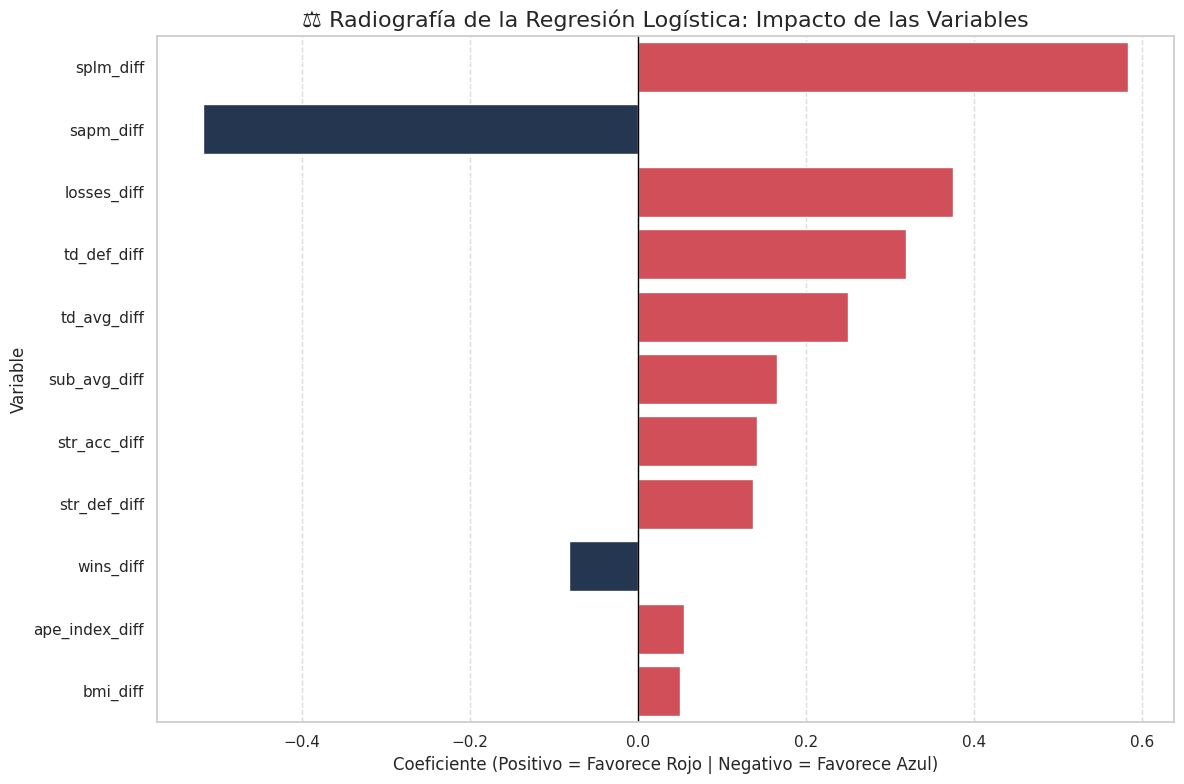

In [87]:
 # 1. Extraer el "cerebro" (el modelo de Regresión Logística) de tu pipeline
# Asegúrate de que el nombre 'classifier' coincida con el paso en tu Pipeline
lr_model = pipeline_definitivo.named_steps['classifier']

# 2. Extraer los nombres de las variables (directamente de X_sim, ya que el preprocesamiento se hizo antes)
# X_sim contiene las features que fueron directamente al modelo 'lr'
todas_las_features = X_sim.columns.tolist()

# 3. Extraer los COEFICIENTES de la Regresión Logística
coeficientes = lr_model.coef_[0]

# Crear un DataFrame
importancias_lr = pd.DataFrame({
    'Variable': todas_las_features,
    'Coeficiente': coeficientes
})

# Creamos una columna con el Valor Absoluto para ver la "Fuerza" real de la variable
importancias_lr['Fuerza_Absoluta'] = importancias_lr['Coeficiente'].abs()

# Ordenamos por la fuerza absoluta (de mayor impacto a menor impacto)
importancias_lr = importancias_lr.sort_values(by='Fuerza_Absoluta', ascending=False)

# Creamos una columna de color: Verde si favorece al Rojo (+), Rojo si favorece al Azul (-)
importancias_lr['Color'] = np.where(importancias_lr['Coeficiente'] > 0, '#E63946', '#1D3557') # Rojo y Azul

# 4. Graficar el Top 15 de variables más determinantes
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Coeficiente',
    y='Variable',
    data=importancias_lr.head(15),
    palette=importancias_lr.head(15)['Color'].tolist()
)

plt.title('⚖️ Radiografía de la Regresión Logística: Impacto de las Variables', fontsize=16)
plt.xlabel('Coeficiente (Positivo = Favorece Rojo | Negativo = Favorece Azul)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.axvline(0, color='black', linestyle='-', linewidth=1) # Línea central en el 0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- REPORTE DEL MODELO DE REGRESIÓN LOGÍSTICA (en dataset simétrico) ---
               precision    recall  f1-score   support

Gana Azul (0)       0.67      0.67      0.67      7998
Gana Rojo (1)       0.67      0.67      0.67      7998

     accuracy                           0.67     15996
    macro avg       0.67      0.67      0.67     15996
 weighted avg       0.67      0.67      0.67     15996



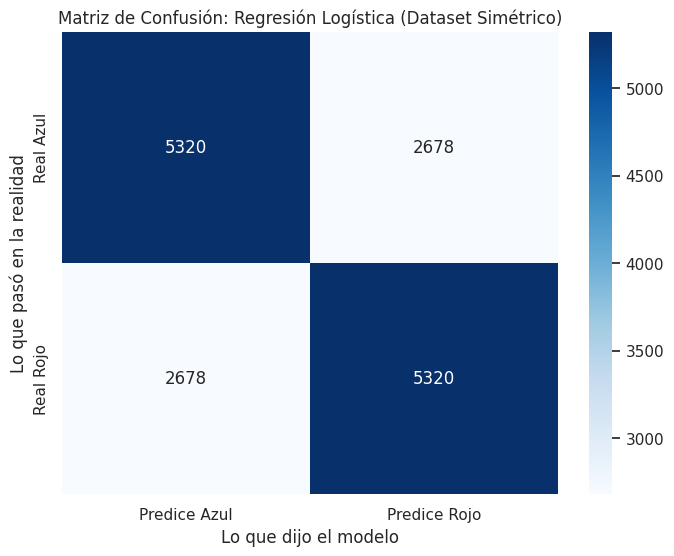

In [88]:
pipeline_lr = Pipeline(steps=[
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_sim, y_sim)

y_pred_lr = pipeline_lr.predict(X_sim)

print("--- REPORTE DEL MODELO DE REGRESIÓN LOGÍSTICA (en dataset simétrico) ---")
print(classification_report(y_sim, y_pred_lr, target_names=['Gana Azul (0)', 'Gana Rojo (1)']))

cm_lr = confusion_matrix(y_sim, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice Azul', 'Predice Rojo'],
            yticklabels=['Real Azul', 'Real Rojo'])
plt.title('Matriz de Confusión: Regresión Logística (Dataset Simétrico)')
plt.xlabel('Lo que dijo el modelo')
plt.ylabel('Lo que pasó en la realidad')
plt.show()

In [89]:
def simular_pelea_final(peleador_A, peleador_B, df_peleadores, pipeline_modelo, columnas_entrenamiento):
    # 1. Buscar a los peleadores
    try:
        A = df_peleadores[df_peleadores['name'] == peleador_A].iloc[0]
        B = df_peleadores[df_peleadores['name'] == peleador_B].iloc[0]
    except IndexError:
        return "❌ Peleador no encontrado en la base de datos."

    # --- 🚨 CONTROL DE COMISIÓN ATLÉTICA ESTRICTO (KILOS A LIBRAS) 🚨 ---
    NOMBRE_COLUMNA_PESO = 'weight'

    if NOMBRE_COLUMNA_PESO not in df_peleadores.columns:
        print(f"🚫 SIMULACIÓN CANCELADA: No encuentro la columna '{NOMBRE_COLUMNA_PESO}'.")
        return

    try:
        # Extraemos los números (que en tu dataset están en kilos)
        peso_A_kg = float(re.sub(r'[^\d.]', '', str(A[NOMBRE_COLUMNA_PESO])))
        peso_B_kg = float(re.sub(r'[^\d.]', '', str(B[NOMBRE_COLUMNA_PESO])))

        # ¡LA MAGIA! Convertimos los kilos a libras para comparar con la UFC
        peso_A_lbs = peso_A_kg * 2.20462
        peso_B_lbs = peso_B_kg * 2.20462

        # Divisiones oficiales de la UFC en libras
        divisiones = [115, 125, 135, 145, 155, 170, 185, 205, 265]

        # Encontramos la división más cercana
        indice_A = min(range(len(divisiones)), key=lambda i: abs(divisiones[i] - peso_A_lbs))
        indice_B = min(range(len(divisiones)), key=lambda i: abs(divisiones[i] - peso_B_lbs))

        diferencia_saltos = abs(indice_A - indice_B)

        if diferencia_saltos > 1:
            print("\n⚖️ COMBATE DENEGADO POR LA COMISIÓN ATLÉTICA ⚖️")
            print("-" * 40)
            print(f"🔴 {peleador_A} ({divisiones[indice_A]} lbs / {peso_A_kg:.1f} kg)")
            print(f"🔵 {peleador_B} ({divisiones[indice_B]} lbs / {peso_B_kg:.1f} kg)")
            print("❌ Diferencia ilegal de peso. Simulación abortada.")
            print("-" * 40)
            return

    except Exception as e:
        print(f"🚫 ERROR al leer los pesos: {e}")
        return
    # --------------------------------------------------------

    # 2. Calcular las diferencias (Solo las métricas de combate)
    datos_dict = {
        'ape_index_diff': A['ape_index'] - B['ape_index'],
        'bmi_diff': A['BMI'] - B['BMI'],
        'splm_diff': A['splm'] - B['splm'],
        'sapm_diff': A['sapm'] - B['sapm'],
        'str_acc_diff': (A['str_acc'] - B['str_acc']) / 100,
        'str_def_diff': (A['str_def'] - B['str_def']) / 100,
        'td_avg_diff': A['td_avg'] - B['td_avg'],
        'td_def_diff': A['td_def'] - B['td_def'],
        'sub_avg_diff': A['sub_avg'] - B['sub_avg'],
        'wins_diff': A['wins'] - B['wins'],
        'losses_diff': A['losses'] - B['losses']
    }

    # Creamos el DataFrame y rellenamos
    df_pred = pd.DataFrame([datos_dict])
    for col in columnas_entrenamiento:
        if col not in df_pred.columns:
            df_pred[col] = 0
    df_pred = df_pred[columnas_entrenamiento]

    # 3. Predicción
    probabilidades = pipeline_modelo.predict_proba(df_pred)[0]
    prob_A = probabilidades[1] * 100
    prob_B = probabilidades[0] * 100

    # 4. Imprimir resultados
    print(f"\n🥊 SIMULACIÓN DE COMBATE 🥊")
    print(f"{peleador_A} vs {peleador_B}")
    print("-" * 40)
    print(f"Probabilidad de {peleador_A}: {prob_A:.2f}%")
    print(f"Probabilidad de {peleador_B}: {prob_B:.2f}%")
    print("-" * 40)

# Predicciones
He realizado distintas predicciones para comprobar que tal funciona el modelo en la vida real.

La primera predicción es de un evento que ya se ha realizado el UFC 328 que esté lo pondré en la memoria historica, los de UFC fight night macao que se celebra el 30 mayo después de entregar el TFM y el UFC 250 FREEDOM que se celebra en la casa blanca y lo estelariza ilia topuria el 13 junio.

## Predicción de UFC 328

In [90]:
print("🔥 SIMULACIÓN: UFC 328 - CHIMAEV VS STRICKLAND 🔥\n")

# --- CARTELERA PRINCIPAL (Main Card) ---
print("================ CARTELERA PRINCIPAL ================")

# Main Event (Campeonato de Peso Medio)
simular_pelea_final('Khamzat Chimaev', 'Sean Strickland', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Co-Main Event (Campeonato de Peso Mosca)
simular_pelea_final('Joshua Van', 'Tatsuro Taira', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Pesado
simular_pelea_final('Alexander Volkov', 'Waldo Cortes-Acosta', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Wélter
simular_pelea_final('Sean Brady', 'Joaquin Buckley', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Ligero
simular_pelea_final('King Green', 'Jeremy Stephens', df_peleadores_limpio, pipeline_lr, X_sim.columns)


# --- PRELIMINARES DESTACADAS (Prelims) ---
print("\n================ PRELIMINARES ================")

# Peso Medio
simular_pelea_final('Ateba Gautier', 'Ozzy Diaz', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Wélter
simular_pelea_final('Yaroslav Amosov', 'Joel Alvarez', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Ligero
simular_pelea_final('Grant Dawson', 'Mateusz Rebecki', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Ligero
simular_pelea_final('Jim Miller', 'Jared Gordon', df_peleadores_limpio, pipeline_lr, X_sim.columns)



🔥 SIMULACIÓN: UFC 328 - CHIMAEV VS STRICKLAND 🔥

================ CARTELERA PRINCIPAL ================

🥊 SIMULACIÓN DE COMBATE 🥊
Khamzat Chimaev vs Sean Strickland
----------------------------------------
Probabilidad de Khamzat Chimaev: 70.02%
Probabilidad de Sean Strickland: 29.98%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Joshua Van vs Tatsuro Taira
----------------------------------------
Probabilidad de Joshua Van: 68.40%
Probabilidad de Tatsuro Taira: 31.60%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Alexander Volkov vs Waldo Cortes-Acosta
----------------------------------------
Probabilidad de Alexander Volkov: 59.91%
Probabilidad de Waldo Cortes-Acosta: 40.09%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Sean Brady vs Joaquin Buckley
----------------------------------------
Probabilidad de Sean Brady: 60.33%
Probabilidad de Joaquin Buckley: 39.67%
----------------------------------------

🥊 SIMULACIÓN D

## Predicción UFC Fight night MACAO

Resultados reales del combate: https://www.ufc.com/event/ufc-fight-night-may-30-2026

In [91]:
print("🔥 SIMULACIÓN OFICIAL: UFC FIGHT NIGHT MACAO (30 Mayo 2026) 🔥\n")

# --- CARTELERA PRINCIPAL (Main Card) ---
print("================ CARTELERA PRINCIPAL ================")

# Main Event (Peso Gallo)
# Nota: Aunque es a 5 asaltos, no hay cinturón en juego, por lo que  0=False
simular_pelea_final('Song Yadong', 'Deiveson Figueiredo', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Co-Main Event (Peso Semipesado)
simular_pelea_final('Zhang Mingyang', 'Alonzo Menifield', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Pesado
simular_pelea_final('Sergei Pavlovich', 'Tallison Teixeira', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Gallo
simular_pelea_final('Kai Asakura', 'Cameron Smotherman', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Wélter
simular_pelea_final('Jake Matthews', 'Carlston Harris', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Mosca
simular_pelea_final('Alex Perez', 'Sumudaerji', df_peleadores_limpio, pipeline_lr, X_sim.columns)


# --- PRELIMINARES DESTACADAS (Prelims) ---
print("\n================ PRELIMINARES ================")

# Peso Paja Femenino (Choque de estilos)
simular_pelea_final('Angela Hill', 'Xiong Jingnan', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Gallo
simular_pelea_final('Rei Tsuruya', 'Luis Gurule', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Gallo
simular_pelea_final('Aoriqileng', 'Cody Haddon', df_peleadores_limpio, pipeline_lr, X_sim.columns)

🔥 SIMULACIÓN OFICIAL: UFC FIGHT NIGHT MACAO (30 Mayo 2026) 🔥

================ CARTELERA PRINCIPAL ================

🥊 SIMULACIÓN DE COMBATE 🥊
Song Yadong vs Deiveson Figueiredo
----------------------------------------
Probabilidad de Song Yadong: 57.01%
Probabilidad de Deiveson Figueiredo: 42.99%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Zhang Mingyang vs Alonzo Menifield
----------------------------------------
Probabilidad de Zhang Mingyang: 71.41%
Probabilidad de Alonzo Menifield: 28.59%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Sergei Pavlovich vs Tallison Teixeira
----------------------------------------
Probabilidad de Sergei Pavlovich: 38.49%
Probabilidad de Tallison Teixeira: 61.51%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Kai Asakura vs Cameron Smotherman
----------------------------------------
Probabilidad de Kai Asakura: 28.27%
Probabilidad de Cameron Smotherman: 71.73%
-------------------------

## Predicción Casa blanca
El evento se celebra el 13 de junio por lo tanto no sé si a la hora de corregirlo ya habrá ocurrido el evento o no

resultados: https://www.ufc.com/event/ufc-freedom-250


In [92]:
print("🔥 SIMULACIÓN: CARTELERA DE LA CASA BLANCA 🔥\n")

print("================ CARTELERA PRINCIPAL ================")

# Main Event (Unificación del Título de Peso Ligero)
simular_pelea_final('Ilia Topuria', 'Justin Gaethje', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Co-Main Event (El salto al Peso Pesado)
simular_pelea_final('Alex Pereira', 'Ciryl Gane', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Gallo
simular_pelea_final("Sean O'Malley", 'Aiemann Zahabi', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Pesado (El Rey del KO)
simular_pelea_final('Josh Hokit', 'Derrick Lewis', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Ligero (Choque Generacional)
simular_pelea_final('Mauricio Ruffy', 'Michael Chandler', df_peleadores_limpio, pipeline_lr, X_sim.columns )

# Peso Medio (La prueba de fuego del prospecto)
simular_pelea_final('Bo Nickal', 'Kyle Daukaus', df_peleadores_limpio, pipeline_lr, X_sim.columns)

# Peso Pluma (Guerra de finalizadores)
simular_pelea_final('Diego Lopes', 'Steve Garcia', df_peleadores_limpio, pipeline_lr, X_sim.columns)

🔥 SIMULACIÓN: CARTELERA DE LA CASA BLANCA 🔥

================ CARTELERA PRINCIPAL ================

🥊 SIMULACIÓN DE COMBATE 🥊
Ilia Topuria vs Justin Gaethje
----------------------------------------
Probabilidad de Ilia Topuria: 70.74%
Probabilidad de Justin Gaethje: 29.26%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Alex Pereira vs Ciryl Gane
----------------------------------------
Probabilidad de Alex Pereira: 41.77%
Probabilidad de Ciryl Gane: 58.23%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Sean O'Malley vs Aiemann Zahabi
----------------------------------------
Probabilidad de Sean O'Malley: 71.28%
Probabilidad de Aiemann Zahabi: 28.72%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Mauricio Ruffy vs Michael Chandler
----------------------------------------
Probabilidad de Mauricio Ruffy: 38.88%
Probabilidad de Michael Chandler: 61.12%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Bo Nicka

Dejo esta ultima casilla por si queréis testear.

In [93]:
simular_pelea_final('Alexander Volkanovski', 'Ciryl Gane', df_peleadores_limpio, pipeline_lr, X_sim.columns )
simular_pelea_final('Arnold Allen','Melquizael Costa', df_peleadores_limpio, pipeline_lr, X_sim.columns)
simular_pelea_final('Charles Oliveira','Max Holloway', df_peleadores_limpio, pipeline_lr, X_sim.columns)
simular_pelea_final('Song Yadong','Deiveson Figueiredo', df_peleadores_limpio, pipeline_lr, X_sim.columns)


⚖️ COMBATE DENEGADO POR LA COMISIÓN ATLÉTICA ⚖️
----------------------------------------
🔴 Alexander Volkanovski (145 lbs / 65.8 kg)
🔵 Ciryl Gane (265 lbs / 111.1 kg)
❌ Diferencia ilegal de peso. Simulación abortada.
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Arnold Allen vs Melquizael Costa
----------------------------------------
Probabilidad de Arnold Allen: 33.57%
Probabilidad de Melquizael Costa: 66.43%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Charles Oliveira vs Max Holloway
----------------------------------------
Probabilidad de Charles Oliveira: 45.46%
Probabilidad de Max Holloway: 54.54%
----------------------------------------

🥊 SIMULACIÓN DE COMBATE 🥊
Song Yadong vs Deiveson Figueiredo
----------------------------------------
Probabilidad de Song Yadong: 57.01%
Probabilidad de Deiveson Figueiredo: 42.99%
----------------------------------------


### Exportar el Modelo Entrenado

Guardaremos el modelo entrenado (`pipeline_definitivo`) en un archivo utilizando la librería `joblib`. Esto permite reutilizar el modelo sin necesidad de volver a entrenarlo, lo cual es útil para despliegue o para continuar con análisis en otro momento.

In [94]:
import joblib

# Nombre del archivo para guardar el modelo
model_filename = 'modelo_prediccion_ufc.joblib'

# Guardar el pipeline completo
joblib.dump(pipeline_definitivo, model_filename)

print(f"Modelo guardado exitosamente como '{model_filename}'")

Modelo guardado exitosamente como 'modelo_prediccion_ufc.joblib'
